# Key metrics - DRG C

Sources:

See the "income and budget data" notebook for data assembly
- Municipal Fiscal indicators: https://data.ct.gov/browse?tags=2023+municipal+fiscal+indicators&sortBy=relevance&pageSize=20
- Equalized net grand list: https://portal.ct.gov/OPM/IGPP/IGPP-Home
- Municipal expenses by function https://data.ct.gov/Local-Government/Municipal-Fiscal-Indicators-Uniform-Chart-of-Accou/3gbm-qe5e/about_data
- Municipal Spending data: https://catalog.data.gov/dataset/uniform-chart-of-accounts-municipal-spending-data
- IRS tax return information by ZIP: https://www.irs.gov/statistics/soi-tax-stats-individual-income-tax-statistics-zip-code-data-soi
- OASDI (Social Security) by ZIP and year: https://www.ssa.gov/policy/docs/statcomps/oasdi_zip/2022/index.html

## Select peer group

Useful options include `peer', 'elite', 'aspirational', 'augmented', 'betters', 'peerplus', 'affordable', 'pca', 'finproj', 'finprojB', 'urban'`

In [1]:
# select peer group
PEERVAR = 'finproj'
PEERVAL = 'DRG C'

In [2]:
import os.path as path
import os 
from os import mkdir
import re
from datetime import datetime
import numpy as np
from scipy import stats
import polars as pl
import pandas as pd
pd.options.display.html.use_mathjax = False

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Set the rcParam "text.usetex" to False
plt.rcParams["text.usetex"] = False

## Functions

In [3]:
# Define a custom formatter function

def dollar_i(x, pos):
    return f"${x:,.0f}"
    
def dollar_k(x, pos):
    return f"${int(x/1000):,}K"

# for when data is "in thousands"
def dollar_mm(x, pos):
    return f"${int(x/1000):,}MM"

# for when data is "in thousands"
def dollar_bb(x, pos):
    return f"${(x/1000000):,.1f}B"

# for when data is "in ones" - actual million
def dollar_realmm(x, pos):
    return f"${(x/1000000):,.1f}MM"
    
# for when data is "in ones" - actual billion
def dollar_realbb(x, pos):
    return f"${(x/1000000000):,.1f}B"
    
def comma(x, pos):
    return f"{int(x):,}"

def qty_k(x, pos):
    return f"{(x/1000):,.1f}K"

def percfmt(x, pos):
    return f"{x:.1%}"

def perc2fmt(x, pos):
    return f"{x:.2%}"
    
def percifmt(x, pos):
    return f"{x:.0%}"
    
# Apply the formatter to the y-axis
dollari_formatter = ticker.FuncFormatter(dollar_i)
dollar_k_formatter = ticker.FuncFormatter(dollar_k)
dollar_bb_formatter = ticker.FuncFormatter(dollar_bb)
dollar_realbb_formatter = ticker.FuncFormatter(dollar_realbb)
dollar_mm_formatter = ticker.FuncFormatter(dollar_mm)
dollar_realmm_formatter = ticker.FuncFormatter(dollar_realmm)
perc_formatter = ticker.FuncFormatter(percfmt)
perc2_formatter = ticker.FuncFormatter(perc2fmt)
perci_formatter = ticker.FuncFormatter(percifmt)

k_formatter = ticker.FuncFormatter(qty_k)
comma_formatter = ticker.FuncFormatter(comma)

In [4]:
# for plotting
rundate = datetime.now().strftime('%a %d %b %Y %H:%M:%S EDT')
software = f"Seaborn={sns.__version__}"

png_metadata = {
'Title': "Social Security Income",
'Author': 'Joel Danke',
'Description': "Based on OASDI data https://www.ssa.gov/policy/docs/statcomps/oasdi_zip/2022/index.html",
'Creation Time': rundate,
'Software': software}

## Import data
### File locations

In [5]:
# will split this into total & by-band rows
town_incomes = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/town_incomes.parquet')
town_ssi = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/town_ssi.parquet')
district_total_income = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/district_incomes.parquet')
district_accounts = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/district_chart_of_accounts.parquet')
accounts = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/town_chart_of_accounts.parquet')

In [6]:
#make directory if needed
try:
    mkdir(f"./charts/budget/{PEERVAR}")
except FileExistsError:
    pass

## Analysis
### Split to totals and band

In [7]:
town_band_income = town_incomes[town_incomes['Size of adjusted gross income'] != 'Total'].copy()
town_total_income = town_incomes[town_incomes['Size of adjusted gross income'] == 'Total'].copy()

### Granby Key Stats
Per Taxpayer is from IRS data using counts of returns filed jointly, single, or head of household. Married couples double the number shown.

In [8]:
# key stats
qty = ['Number of returns', 'Number of elderly returns', 'Taxpayers', 'Number of individuals', 'Average School Enrollment']
perc = [ 'Education Share Of Income', 'Taxes Share Of Income', 'Education Share Of Budget', 'Debt Service Share Of Budget']
dolr = ['Income Per Taxpayer (2024 dollars)', 'Flat Tax Per Taxpayer (2024 dollars)']
key_stats = ['Year'] +  qty + dolr + perc 
town_total_income.query('Town == "Granby"')[key_stats]\
    .style.format({x:"{:,.0f}" for x in qty} | {x: "{:.1%}" for x in perc} | {x : "${:,.0f}" for x in dolr})

,Year,Number of returns,Number of elderly returns,Taxpayers,Number of individuals,Average School Enrollment,Income Per Taxpayer (2024 dollars),Flat Tax Per Taxpayer (2024 dollars),Education Share Of Income,Taxes Share Of Income,Education Share Of Budget,Debt Service Share Of Budget
4248,2013,"5,520",0,"8,250",0,"2,024","$88,733","$5,195",5.4%,5.9%,70.7%,8.0%
4255,2014,"5,480",0,"8,220",0,"1,948","$91,408","$5,318",5.3%,5.8%,70.3%,7.7%
4262,2015,"5,520","1,640","8,240",0,"1,921","$94,476","$5,425",5.1%,5.8%,69.9%,8.4%
4269,2016,"5,480","1,660","8,200",0,"1,836","$90,813","$5,508",5.7%,6.1%,70.9%,7.6%
4276,2017,"5,520","1,730","8,230",0,"1,827","$92,515","$5,492",5.7%,6.0%,71.7%,7.3%
4283,2018,"5,530","1,820","8,250","10,790","1,833","$97,787","$5,652",4.9%,5.8%,69.9%,7.4%
4290,2019,"5,660","1,880","8,400","10,870","1,759","$94,155","$5,683",5.2%,6.1%,71.9%,5.8%
4297,2020,"5,760","1,940","8,470","10,920","1,694","$93,583","$5,645",5.4%,6.1%,72.3%,4.4%
4304,2021,"5,700","2,000","8,380","10,780","1,725","$103,691","$5,470",4.8%,5.3%,70.8%,3.5%
4311,2022,"5,790","2,080","8,500","10,950","1,690","$96,726","$5,211",5.1%,5.4%,74.0%,3.7%


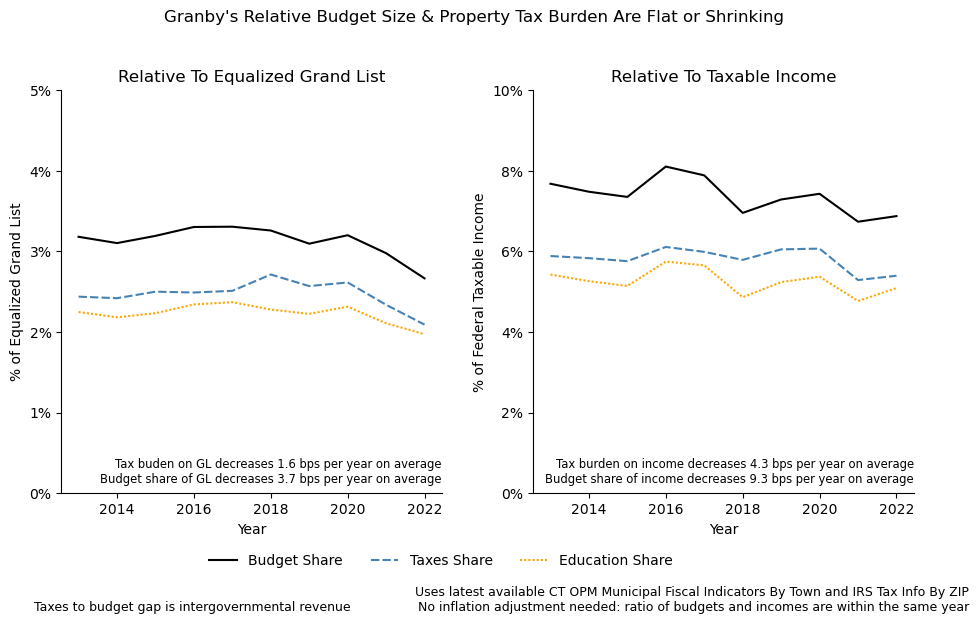

In [9]:
granby_buds = pd.melt(town_total_income.query('Town == "Granby"'), id_vars ='Year',
                        value_vars=['Budget Share Of Income', 'Budget Share Of Eq Grand List',
                                    'Taxes Share Of Income', 'Taxes Share Of Eq Grand List',
                                    'Education Share Of Income', 'Education Share Of Eq Grand List'],
                        var_name='Measure', value_name='Share')

# univariate regressions
# share of income
X = granby_buds[granby_buds['Measure'] == 'Taxes Share Of Income']
x = X['Year'].values
y = X['Share'].values
slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)
bps = np.round(slope*10000, 1)
direction = 'increases' if bps > 0 else 'decreases'
bps = abs(bps)

X = granby_buds[granby_buds['Measure'] == 'Budget Share Of Income']
x = X['Year'].values
y = X['Share'].values
slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)
bps2 = np.round(slope*10000, 1)
direction2 = 'increases' if bps2 > 0 else 'decreases'
bps2 = abs(bps2)

# share of grand list
X = granby_buds[granby_buds['Measure'] == 'Taxes Share Of Eq Grand List']
x = X['Year'].values
y = X['Share'].values
slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)
bps3 = np.round(slope*10000, 1)
direction3 = 'increases' if bps3 > 0 else 'decreases'
bps3 = abs(bps3)

X = granby_buds[granby_buds['Measure'] == 'Budget Share Of Eq Grand List']
x = X['Year'].values
y = X['Share'].values
slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)
bps4 = np.round(slope*10000, 1)
direction4 = 'increases' if bps4 > 0 else 'decreases'
bps4 = abs(bps4)


# plots
fig, axs = plt.subplots(1, 2, figsize=(11, 6.2), gridspec_kw={'wspace':.24} )

fig.suptitle("Granby's Relative Budget Size & Property Tax Burden Are Flat or Shrinking")

# relative to grand list
sns.lineplot(granby_buds.query('Measure.str.endswith("List")'),
             x='Year', y='Share', hue='Measure', style='Measure',
             palette=['black', 'steelblue', 'orange'],
             ax = axs[0], legend=None)
axs[0].set_title("Relative To Equalized Grand List")
axs[0].set_ylabel("% of Equalized Grand List")
axs[0].set_ylim(0,.05)
_l, _h = axs[0].get_xlim()
axs[0].text(_h, 0.001, f"Tax buden on GL {direction3} {bps3} bps per year on average\n" +
            f"Budget share of GL {direction4} {bps4} bps per year on average", 
            fontsize='small', ha='right', va='bottom')

# relative to income
sns.lineplot(granby_buds.query('Measure.str.endswith("Income")'), x='Year', y='Share',
             hue='Measure', style='Measure',
             palette=['black', 'steelblue', 'orange'],
             ax = axs[1])
axs[1].set_title("Relative To Taxable Income")
axs[1].set_ylabel("% of Federal Taxable Income")
axs[1].set_ylim(0,.1)
_l, _h = axs[1].get_xlim()
axs[1].text(_h, 0.002, f"Tax burden on income {direction} {bps} bps per year on average\n" + 
                       f"Budget share of income {direction2} {bps2} bps per year on average", 
            fontsize='small', ha='right', va='bottom')

# modify legend
h, lab = axs[1].get_legend_handles_labels()
axs[1].legend(h, [" ".join(l.split()[0:2]) for l in lab])

for ax in axs:
    ax.yaxis.set_major_formatter(perci_formatter)

sns.move_legend(axs[1], "upper right", bbox_to_anchor=(0.4, -0.12), ncols=3, frameon=False)
sns.despine()


plt.subplots_adjust(top=.85, bottom=0.2)

line1 = "Uses latest available CT OPM Municipal Fiscal Indicators By Town and IRS Tax Info By ZIP\n"
line2 = "No inflation adjustment needed: ratio of budgets and incomes are within the same year"
fig.text(.95, .01, line1 + line2, fontsize=9, ha='right')
fig.text(0.1, .01, "Taxes to budget gap is intergovernmental revenue", fontsize=9, ha='left')

plt.savefig(f"./charts/budget/{PEERVAR}/budget_share_shrinking.png", dpi=200, metadata=png_metadata)

plt.show()

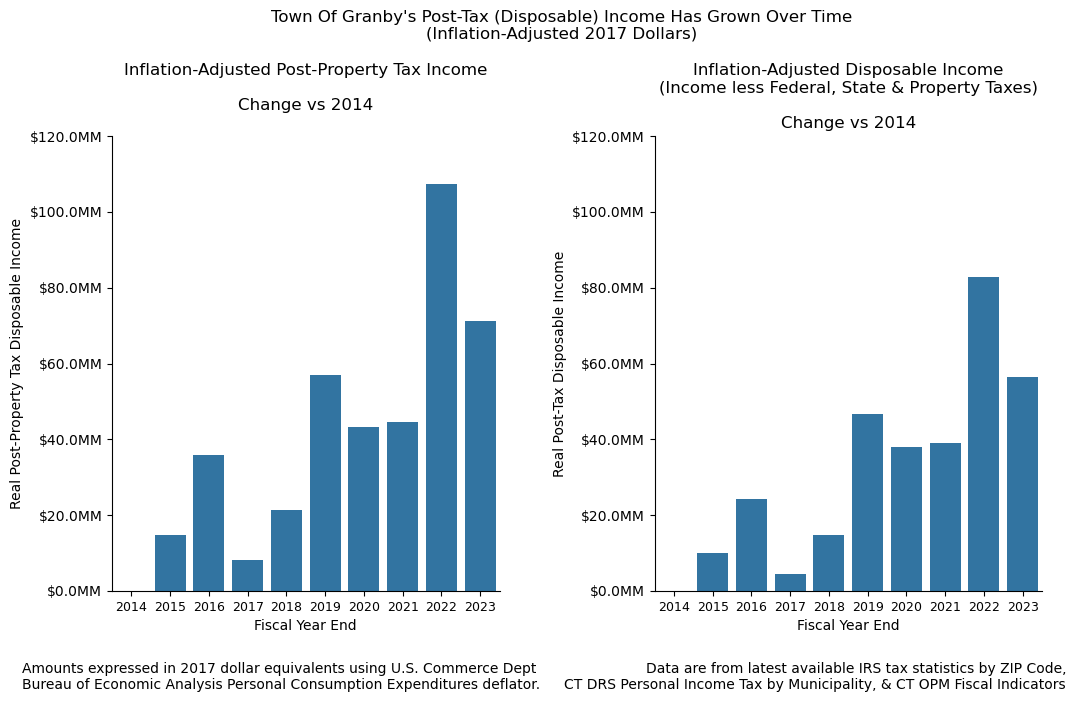

In [66]:
tmpdf = town_total_income.query('Town == "Granby"').copy()
tmpdf['Real Post-Property Tax Disposable Income'] = (tmpdf['Real Post-Local Tax Disposable Income'] - 
                                                  tmpdf['Real Post-Local Tax Disposable Income'].min())

tmpdf['Real Post-Tax Disposable Income'] = (tmpdf['Real Post-Tax Disposable Income'] - 
                                                  tmpdf['Real Post-Tax Disposable Income'].min())


fig, axs = plt.subplots(1, 2, figsize=(12,7), gridspec_kw={'wspace':.4})

fig.suptitle("Town Of Granby's Post-Tax (Disposable) Income Has Grown Over Time\n(Inflation-Adjusted 2017 Dollars)")

ax = axs[0]
ax = sns.barplot(data=tmpdf,
                 y='Real Post-Property Tax Disposable Income',
                 x='Fiscal Year End', ax=ax)
sns.despine()
ax.set_ylim(0,120000000)
ax.set_title('Inflation-Adjusted Post-Property Tax Income\n\nChange vs 2014\n', x=.5)
ax.yaxis.set_major_formatter(dollar_realmm_formatter)
for tick in ax.get_xticklabels():
    tick.set_fontsize(9)

ax = axs[1]
ax = sns.barplot(data=tmpdf,
                 y='Real Post-Tax Disposable Income',
                 x='Fiscal Year End',
               ax = ax)

ax.set_ylim(0,120000000)
ax.set_title('Inflation-Adjusted Disposable Income\n(Income less Federal, State & Property Taxes)\n\nChange vs 2014')
ax.yaxis.set_major_formatter(dollar_realmm_formatter)
for tick in ax.get_xticklabels():
    tick.set_fontsize(9)

#plt.tight_layout()
plt.subplots_adjust(top=.8, bottom=0.15)

line1 = "Amounts expressed in 2017 dollar equivalents using U.S. Commerce Dept\n"
line2 = "Bureau of Economic Analysis Personal Consumption Expenditures deflator."
fig.text(.05, .01, line1 + line2, ha='left')
line2 = "Data are from latest available IRS tax statistics by ZIP Code,\n"
line3 = "CT DRS Personal Income Tax by Municipality, & CT OPM Fiscal Indicators"
fig.text(.92, .01, line2 + line3, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/increasing_disposable_income.png", dpi=200, metadata=png_metadata)

plt.show()

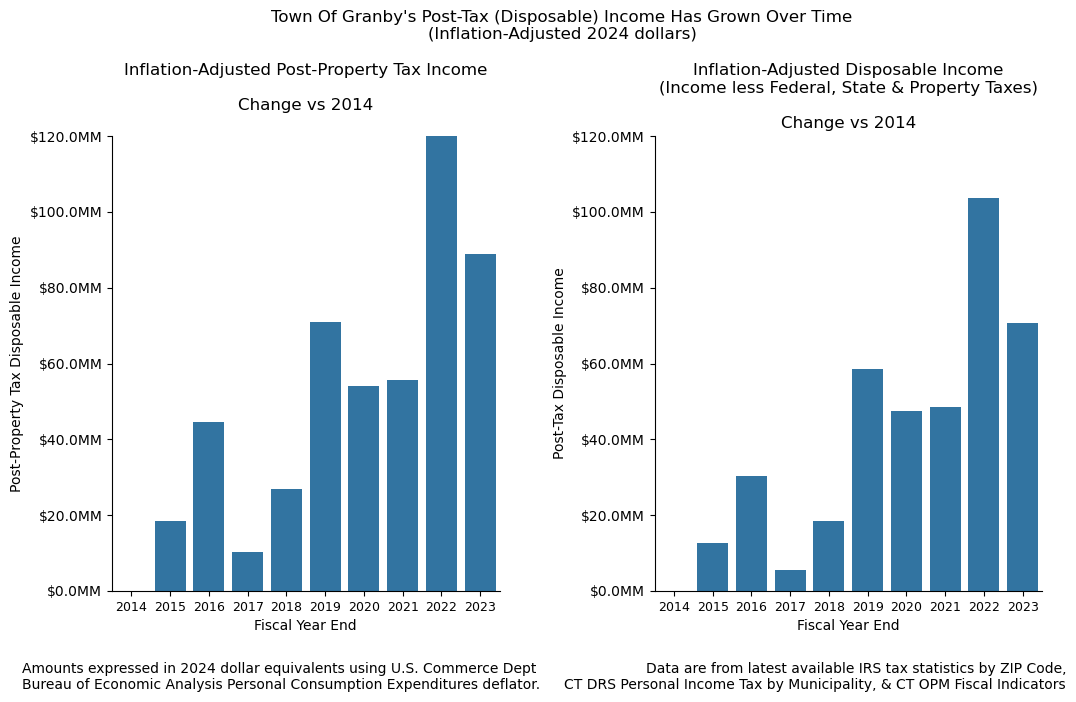

In [11]:
# use 2024 dollars
tmpdf = town_total_income.query('Town == "Granby"').copy()
tmpdf['Post-Property Tax Disposable Income'] = (tmpdf['Post-Local Tax Disposable Income (2024 dollars)'] - 
                                                  tmpdf['Post-Local Tax Disposable Income (2024 dollars)'].min())

tmpdf['Post-Tax Disposable Income'] = (tmpdf['Post-Tax Disposable Income (2024 dollars)'] - 
                                                  tmpdf['Post-Tax Disposable Income (2024 dollars)'].min())


fig, axs = plt.subplots(1, 2, figsize=(12,7), gridspec_kw={'wspace':.4})

fig.suptitle("Town Of Granby's Post-Tax (Disposable) Income Has Grown Over Time\n(Inflation-Adjusted 2024 dollars)")

ax = axs[0]
ax = sns.barplot(data=tmpdf,
                 y='Post-Property Tax Disposable Income',
                 x='Fiscal Year End', ax=ax)
sns.despine()
ax.set_ylim(0,120000000)
ax.set_title('Inflation-Adjusted Post-Property Tax Income\n\nChange vs 2014\n', x=.5)
ax.yaxis.set_major_formatter(dollar_realmm_formatter)
for tick in ax.get_xticklabels():
    tick.set_fontsize(9)

ax = axs[1]
ax = sns.barplot(data=tmpdf,
                 y='Post-Tax Disposable Income',
                 x='Fiscal Year End',
               ax = ax)

ax.set_ylim(0,120000000)
ax.set_title('Inflation-Adjusted Disposable Income\n(Income less Federal, State & Property Taxes)\n\nChange vs 2014')
ax.yaxis.set_major_formatter(dollar_realmm_formatter)
for tick in ax.get_xticklabels():
    tick.set_fontsize(9)

#plt.tight_layout()
plt.subplots_adjust(top=.8, bottom=0.15)

line1 = "Amounts expressed in 2024 dollar equivalents using U.S. Commerce Dept\n"
line2 = "Bureau of Economic Analysis Personal Consumption Expenditures deflator."
fig.text(.05, .01, line1 + line2, ha='left')
line2 = "Data are from latest available IRS tax statistics by ZIP Code,\n"
line3 = "CT DRS Personal Income Tax by Municipality, & CT OPM Fiscal Indicators"
fig.text(.92, .01, line2 + line3, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/increasing_disposable_income_2024.png", dpi=200, metadata=png_metadata)

plt.show()

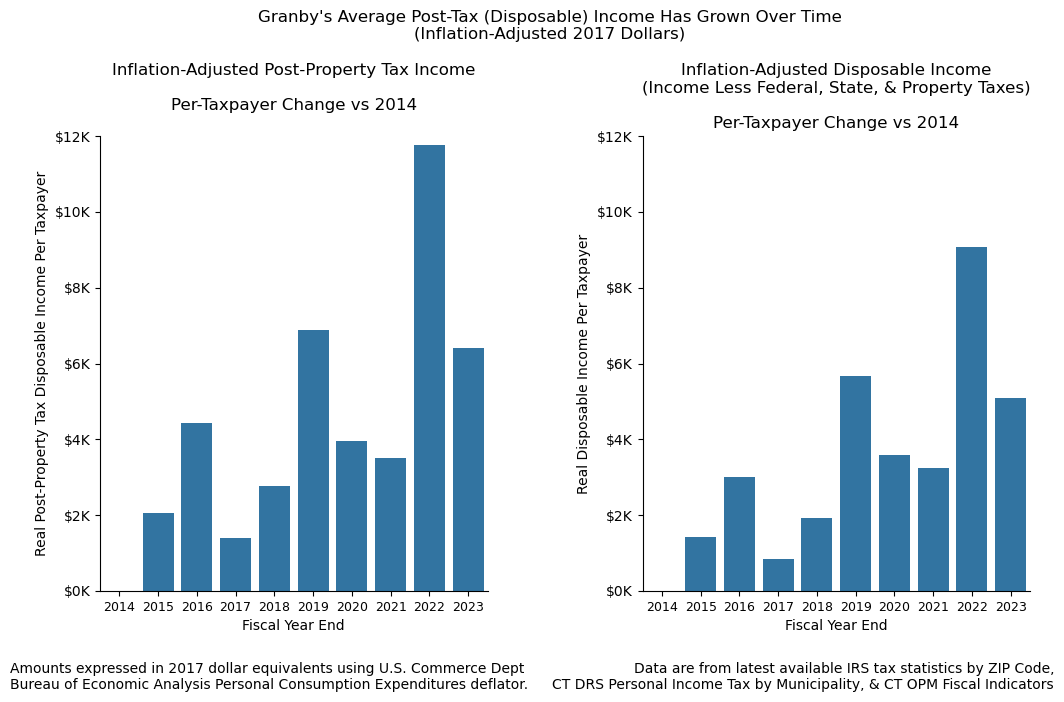

In [65]:
# per-taxpayer 
tmpdf = town_total_income.query('Town == "Granby"').copy()

tmpdf['Real Post-Property Tax Disposable Income Per Taxpayer'] = (tmpdf['Real Post-Local Tax Disposable Income Per Taxpayer'] - 
                                                  tmpdf['Real Post-Local Tax Disposable Income Per Taxpayer'].min())

tmpdf['Real Disposable Income Per Taxpayer'] = (tmpdf['Real Disposable Income Per Taxpayer'] - 
                                                  tmpdf['Real Disposable Income Per Taxpayer'].min())


fig, axs = plt.subplots(1, 2, figsize=(12,7), gridspec_kw={'wspace':.4})

fig.suptitle("Granby's Average Post-Tax (Disposable) Income Has Grown Over Time\n(Inflation-Adjusted 2017 Dollars)")

ax = axs[0]
ax = sns.barplot(data=tmpdf,
                 y='Real Post-Property Tax Disposable Income Per Taxpayer',
                 x='Fiscal Year End', ax=ax)
sns.despine()
ax.set_ylim(0,12000)
ax.set_title('Inflation-Adjusted Post-Property Tax Income\n\nPer-Taxpayer Change vs 2014\n', x=.5)
ax.yaxis.set_major_formatter(dollar_k_formatter)
for tick in ax.get_xticklabels():
    tick.set_fontsize(9)

ax = axs[1]
ax = sns.barplot(data=tmpdf,
                 y='Real Disposable Income Per Taxpayer',
                 x='Fiscal Year End',
               ax = ax)

ax.set_ylim(0,12000)
ax.set_title('Inflation-Adjusted Disposable Income\n(Income Less Federal, State, & Property Taxes)\n\nPer-Taxpayer Change vs 2014')
ax.yaxis.set_major_formatter(dollar_k_formatter)
for tick in ax.get_xticklabels():
    tick.set_fontsize(9)


plt.subplots_adjust(top=.8, bottom=0.15)

line1 = "Amounts expressed in 2017 dollar equivalents using U.S. Commerce Dept\n"
line2 = "Bureau of Economic Analysis Personal Consumption Expenditures deflator."
fig.text(.05, .01, line1 + line2, ha='left')
line2 = "Data are from latest available IRS tax statistics by ZIP Code,\n"
line3 = "CT DRS Personal Income Tax by Municipality, & CT OPM Fiscal Indicators"
fig.text(.92, .01, line2 + line3, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/increasing_ave_disposable_income.png", dpi=200, metadata=png_metadata)

plt.show()

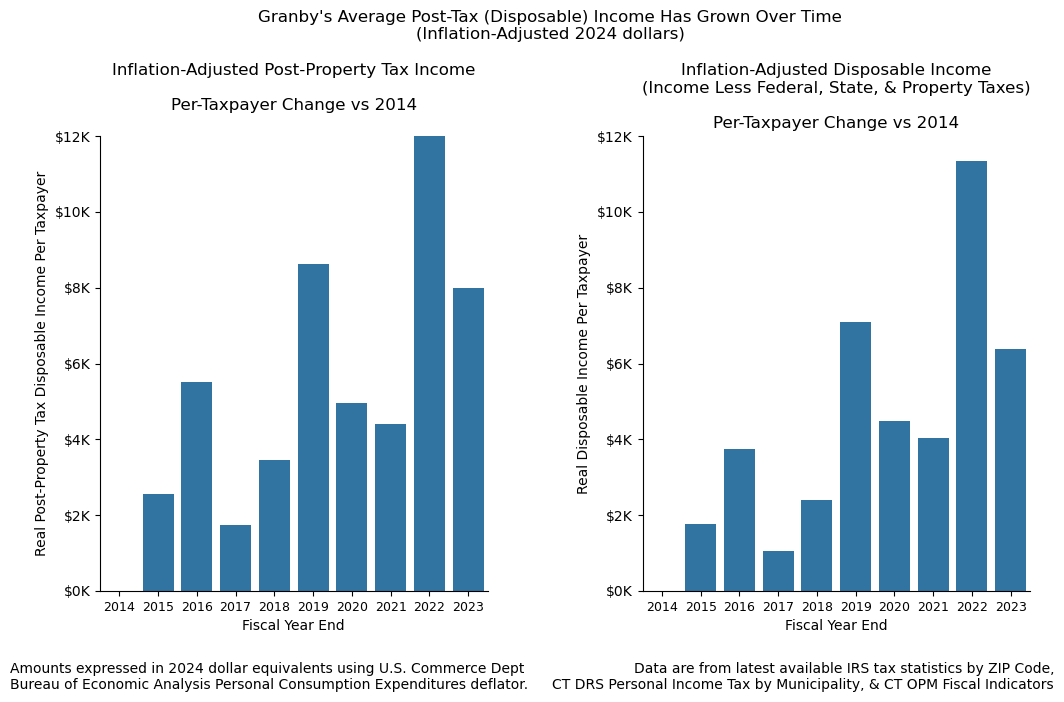

In [13]:
# per-taxpayer  using 2024 dollars
tmpdf = town_total_income.query('Town == "Granby"').copy()

tmpdf['Real Post-Property Tax Disposable Income Per Taxpayer'] = (tmpdf['Post-Local Tax Disposable Income Per Taxpayer (2024 dollars)'] - 
                                                  tmpdf['Post-Local Tax Disposable Income Per Taxpayer (2024 dollars)'].min())

tmpdf['Real Disposable Income Per Taxpayer'] = (tmpdf['Disposable Income Per Taxpayer (2024 dollars)'] - 
                                                  tmpdf['Disposable Income Per Taxpayer (2024 dollars)'].min())


fig, axs = plt.subplots(1, 2, figsize=(12,7), gridspec_kw={'wspace':.4})

fig.suptitle("Granby's Average Post-Tax (Disposable) Income Has Grown Over Time\n(Inflation-Adjusted 2024 dollars)")

ax = axs[0]
ax = sns.barplot(data=tmpdf,
                 y='Real Post-Property Tax Disposable Income Per Taxpayer',
                 x='Fiscal Year End', ax=ax)
sns.despine()
ax.set_ylim(0,12000)
ax.set_title('Inflation-Adjusted Post-Property Tax Income\n\nPer-Taxpayer Change vs 2014\n', x=.5)
ax.yaxis.set_major_formatter(dollar_k_formatter)
for tick in ax.get_xticklabels():
    tick.set_fontsize(9)

ax = axs[1]
ax = sns.barplot(data=tmpdf,
                 y='Real Disposable Income Per Taxpayer',
                 x='Fiscal Year End',
               ax = ax)

ax.set_ylim(0,12000)
ax.set_title('Inflation-Adjusted Disposable Income\n(Income Less Federal, State, & Property Taxes)\n\nPer-Taxpayer Change vs 2014')
ax.yaxis.set_major_formatter(dollar_k_formatter)
for tick in ax.get_xticklabels():
    tick.set_fontsize(9)


plt.subplots_adjust(top=.8, bottom=0.15)

line1 = "Amounts expressed in 2024 dollar equivalents using U.S. Commerce Dept\n"
line2 = "Bureau of Economic Analysis Personal Consumption Expenditures deflator."
fig.text(.05, .01, line1 + line2, ha='left')
line2 = "Data are from latest available IRS tax statistics by ZIP Code,\n"
line3 = "CT DRS Personal Income Tax by Municipality, & CT OPM Fiscal Indicators"
fig.text(.92, .01, line2 + line3, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/increasing_ave_disposable_income_2024.png", dpi=200, metadata=png_metadata)

plt.show()

### School District Comparisons

#### First in general

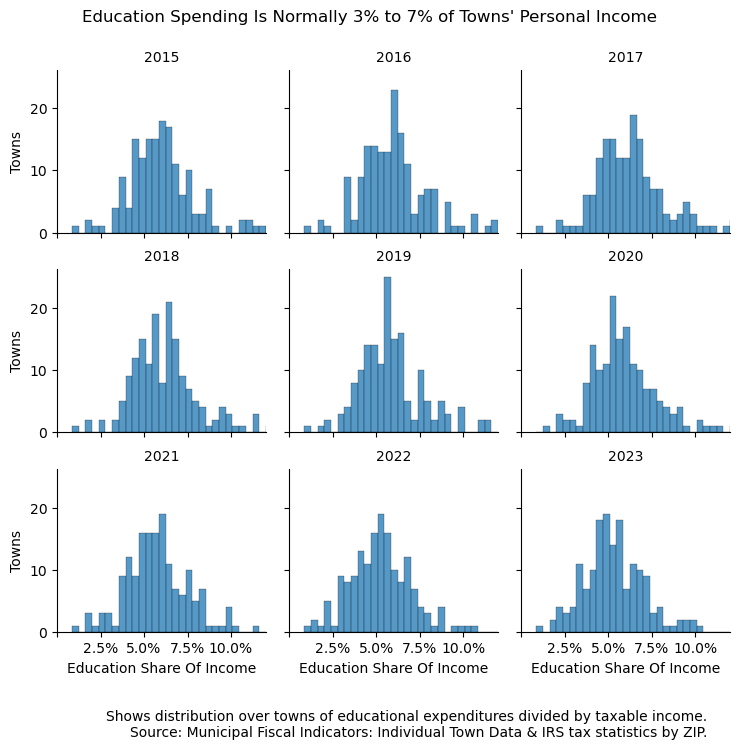

In [14]:
g = sns.displot(data=town_total_income[town_total_income['Fiscal Year End'] >= 2015], x='Education Share Of Income',
            col='Fiscal Year End', col_wrap=3, height=2.5)

g.fig.suptitle("Education Spending Is Normally 3% to 7% of Towns' Personal Income")

g.set_titles(col_template="{col_name}")

for ax in g.axes.flat:
    ax.set_ylabel('Towns')
    ax.set_xlim(0,0.12)
    ax.xaxis.set_major_formatter(perc_formatter)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)

plt.subplots_adjust(top=.9, bottom=0.15)

line1 = "Shows distribution over towns of educational expenditures divided by taxable income.\n"
line2 = "Source: Municipal Fiscal Indicators: Individual Town Data & IRS tax statistics by ZIP."
g.fig.text(.95, .01, line1+line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/education_share_of_income.png", dpi=200, metadata=png_metadata)

plt.show()

### Select peer group
From district-level data

In [15]:
# get data
district_band_income = district_total_income[district_total_income['Size of adjusted gross income'] != 'Total'].copy()
district_total_income = district_total_income[district_total_income['Size of adjusted gross income'] == 'Total'].copy()

# limit to peers
district_total_income = district_total_income[(district_total_income[PEERVAR] > 0)]
district_total_income = district_total_income[district_total_income['Fiscal Year End'] > 2014]
#district_total_income = district_total_income[district_total_income['Fiscal Year End']

# for plotting
district_total_income['Granby'] = (district_total_income[PEERVAR] == 2).astype('int')
district_total_income[PEERVAR] = district_total_income[PEERVAR]\
                                .where(~district_total_income['District'].str.startswith('Region'), 3)

district_total_income.sort_values(by=['Year', PEERVAR, 'Granby'], inplace=True)

#### Color scheme

In [16]:
# color scheme
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in district_total_income['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

peer_cols = {3: (0.19, 0.27, 0.57, .4),
             2: 'black',
             1: (0.529, 0.808, 0.922, .4)}

flag_cols = {0:(0.69, 0.77, 0.87, .4), 1:'black'}

In [17]:
# show districts in peer group
print(f"Using peer variable: {PEERVAR}\n")
for d in sorted(district_total_income[district_total_income[PEERVAR] > 0].District.unique()):
    print(d)

Using peer variable: finproj

Bolton School District
Colchester School District
East Granby School District
East Lyme School District
Ellington School District
Granby School District
Litchfield School District
New Fairfield School District
Newtown School District
North Haven School District
Regional School District 06
Regional School District 10
Regional School District 13
Regional School District 14
Regional School District 17
Regional School District 18
Salem School District
Sherman School District
Somers School District
Southington School District
Stonington School District
Suffield School District
Tolland School District
Woodstock School District


In [18]:
_df = district_total_income[district_total_income['Fiscal Year End'] == 2022]\
    [['District', 'Total income Amount', 'Real Income Per Taxpayer', 'Equalized Net Grand List MM',
      '% Age 65+', '% HH w/Children', 'Enrollment Rate', '% Owner Occ', '% SNAP', '% w/Bachelors+', '% Management']]\
    .rename(columns={'Equalized Net Grand List MM': 'EQ Grand List'}).copy().sort_values('Real Income Per Taxpayer')

_df['District Income'] = _df["Total income Amount"]/1000
_df['EQ Grand List'] = _df['EQ Grand List']/1000
_df[['District', 'District Income', 'EQ Grand List', 'Real Income Per Taxpayer', '% Age 65+', 'Enrollment Rate', '% Owner Occ', '% SNAP', '% w/Bachelors+', '% Management']]\
    .style.format({"District Income": "${:,.0f} B", "EQ Grand List": "${:,.2f} B", "Real Income Per Taxpayer": "${:,.0f}"} |
                  {'Enrollment Rate': "{:.1%}"} |
                  {x: "{:.0f}%" for x in ['% Age 65+', '% Owner Occ', '% SNAP', '% w/Bachelors+', '% Management']})\
    .set_caption("District Comparison - Latest Available Data (2022) Not Adjusted For Inflation")\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])\
    .hide(axis="index")

District,District Income,EQ Grand List,Real Income Per Taxpayer,% Age 65+,Enrollment Rate,% Owner Occ,% SNAP,% w/Bachelors+,% Management
Colchester School District,$798 B,$2.25 B,"$59,544",30%,14.4%,80%,5%,46%,58%
Southington School District,"$2,242 B",$6.34 B,"$63,326",37%,14.1%,84%,4%,42%,51%
Salem School District,$227 B,$0.66 B,"$64,327",32%,13.2%,88%,3%,54%,52%
Woodstock School District,$438 B,$1.42 B,"$65,129",31%,15.0%,85%,1%,45%,47%
East Granby School District,$294 B,$1.01 B,"$68,519",39%,16.2%,81%,10%,48%,38%
North Haven School District,"$1,450 B",$5.00 B,"$69,656",40%,13.3%,82%,4%,47%,52%
Ellington School District,$942 B,$2.15 B,"$70,020",33%,15.4%,70%,3%,50%,62%
Bolton School District,$306 B,$0.75 B,"$73,503",33%,14.7%,90%,4%,48%,58%
Regional School District 10,$947 B,$2.61 B,"$73,506",31%,14.4%,92%,3%,46%,51%
Regional School District 17,$905 B,$2.64 B,"$73,786",35%,12.1%,92%,3%,51%,56%


In [19]:
_df = district_total_income[district_total_income['Fiscal Year End'] == 2022]\
    [['District', 'Total Income (2024 dollars)', 'Income Per Taxpayer (2024 dollars)', 'Equalized Net Grand List MM (2024 dollars)',
      '% Age 65+', '% HH w/Children', 'Enrollment Rate', '% Owner Occ', '% SNAP', '% w/Bachelors+', '% Management']]\
    .copy().sort_values('Income Per Taxpayer (2024 dollars)')

_df['District Income (2024 dollars)'] = _df["Total Income (2024 dollars)"]/1000000
_df['EQ Grand List (2024 dollars)'] = _df['Equalized Net Grand List MM (2024 dollars)']/1000

_df[['District', 'District Income (2024 dollars)', 'EQ Grand List (2024 dollars)', 'Income Per Taxpayer (2024 dollars)', '% Age 65+', 'Enrollment Rate', '% Owner Occ', '% SNAP', '% w/Bachelors+', '% Management']]\
    .style.format({"District Income (2024 dollars)": "${:,.0f} B", "EQ Grand List (2024 dollars)": "${:,.2f} B", "Income Per Taxpayer (2024 dollars)": "${:,.0f}"} |
                  {'Enrollment Rate': "{:.1%}"} |
                  {x: "{:.0f}%" for x in ['% Age 65+', '% Owner Occ', '% SNAP', '% w/Bachelors+', '% Management']})\
    .set_caption("District Comparison - Latest Available Data (2022) Inflation-Adjusted To 2024 Dollars")\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])\
    .hide(axis="index")

District,District Income (2024 dollars),EQ Grand List (2024 dollars),Income Per Taxpayer (2024 dollars),% Age 65+,Enrollment Rate,% Owner Occ,% SNAP,% w/Bachelors+,% Management
Colchester School District,$889 B,$2.51 B,"$74,418",30%,14.4%,80%,5%,46%,58%
Southington School District,"$2,498 B",$7.06 B,"$79,144",37%,14.1%,84%,4%,42%,51%
Salem School District,$253 B,$0.74 B,"$80,395",32%,13.2%,88%,3%,54%,52%
Woodstock School District,$488 B,$1.58 B,"$81,397",31%,15.0%,85%,1%,45%,47%
East Granby School District,$327 B,$1.13 B,"$85,635",39%,16.2%,81%,10%,48%,38%
North Haven School District,"$1,615 B",$5.57 B,"$87,056",40%,13.3%,82%,4%,47%,52%
Ellington School District,"$1,049 B",$2.39 B,"$87,510",33%,15.4%,70%,3%,50%,62%
Bolton School District,$341 B,$0.84 B,"$91,863",33%,14.7%,90%,4%,48%,58%
Regional School District 10,"$1,055 B",$2.91 B,"$91,867",31%,14.4%,92%,3%,46%,51%
Regional School District 17,"$1,008 B",$2.95 B,"$92,218",35%,12.1%,92%,3%,51%,56%


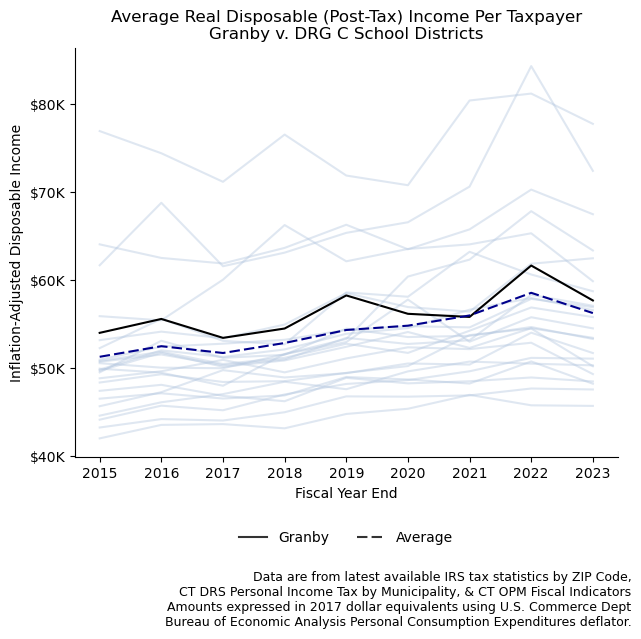

In [20]:
_ave = pd.DataFrame(district_total_income.groupby('Fiscal Year End')['Real Disposable Income Per Taxpayer'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'

tmpdf = pd.concat([district_total_income, _ave], axis=0, ignore_index=True)
tmpdf['Granby'] = 'Other'
tmpdf['Granby'] = tmpdf['Granby'].where(~tmpdf['District'].str.startswith('Granby'), 'Granby')
tmpdf['Granby'] = tmpdf['Granby'].where(~tmpdf['District'].str.startswith('Average'), 'Average')

fig, g = plt.subplots(1, 1, figsize=(7,6.5))
sns.lineplot(data=tmpdf,
                y='Real Disposable Income Per Taxpayer', 
                x='Fiscal Year End', hue='District',
                style='Granby', dashes=[(None, None), (None, None), (5, 2)],
                 ax=g,
                palette=school_cols)
sns.despine()
g.set_title(f'Average Real Disposable (Post-Tax) Income Per Taxpayer\nGranby v. {PEERVAL} School Districts')
g.set_ylabel('Inflation-Adjusted Disposable Income')
g.yaxis.set_major_formatter(dollar_k_formatter)
g.legend()

h, lab = g.get_legend_handles_labels()
g.legend(h[-2:], lab[-2:])
sns.move_legend(g, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncols=2, frameon=False)


plt.subplots_adjust(top=.9, bottom=0.27)

line3 = "Amounts expressed in 2017 dollar equivalents using U.S. Commerce Dept\n"
line4 = "Bureau of Economic Analysis Personal Consumption Expenditures deflator."
line1 = "Data are from latest available IRS tax statistics by ZIP Code,\n"
line2 = "CT DRS Personal Income Tax by Municipality, & CT OPM Fiscal Indicators\n"
fig.text(.92, .01, line1 + line2 + line3 + line4, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/peer_real_disposable_income.png", dpi=200, metadata=png_metadata)

plt.show()

### Relative to incomes

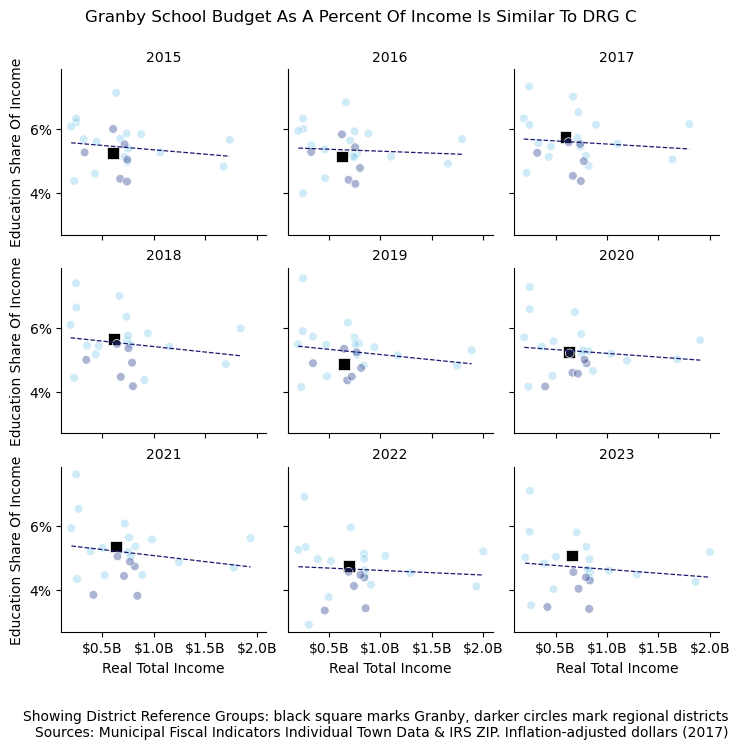

In [21]:
g = sns.relplot(data=district_total_income,
                col='Fiscal Year End', col_wrap=3,
                x='Real Total Income', y='Education Share Of Income',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Real Total Income', y='Education Share Of Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_realbb_formatter)
    #plt.xscale('log') 

g.fig.suptitle(f"Granby School Budget As A Percent Of Income Is Similar To {PEERVAL}")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Inflation-adjusted dollars (2017)"
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/ed_income_share_v_total_income.png", dpi=200, metadata=png_metadata)

plt.show()

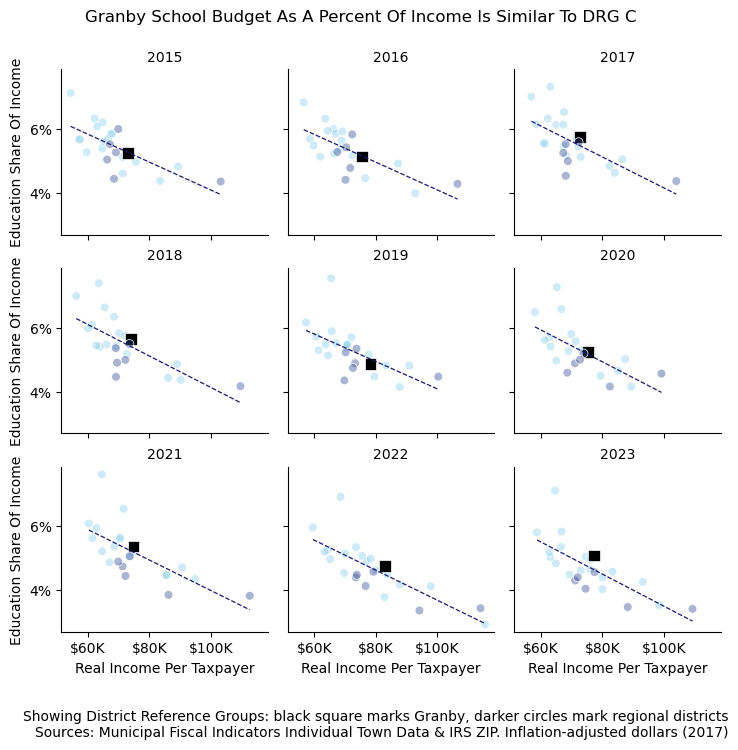

In [22]:
g = sns.relplot(data=district_total_income,
                col='Fiscal Year End', col_wrap=3,
                x='Real Income Per Taxpayer', y='Education Share Of Income',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Real Income Per Taxpayer', y='Education Share Of Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_k_formatter)
    #plt.xscale('log') 

g.fig.suptitle(f"Granby School Budget As A Percent Of Income Is Similar To {PEERVAL}")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Inflation-adjusted dollars (2017)"
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/ed_income_share_v_ave_income.png", dpi=200, metadata=png_metadata)

plt.show()

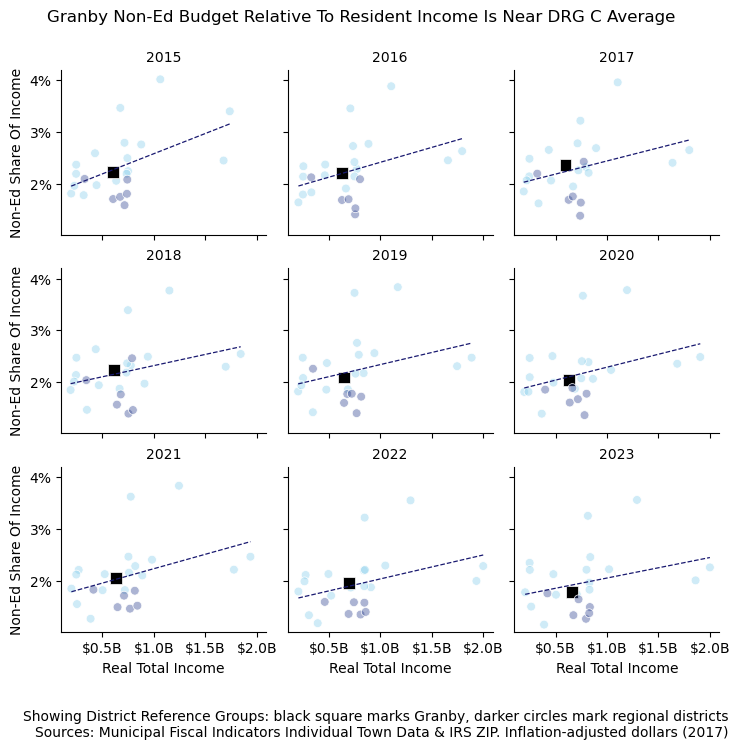

In [23]:
g = sns.relplot(data=district_total_income.rename(columns={'Non-Education Share Of Income': 'Non-Ed Share Of Income'}),
                col='Fiscal Year End', col_wrap=3,
                x='Real Total Income', y='Non-Ed Share Of Income',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Real Total Income', y='Non-Ed Share Of Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.set_ylim(top=.042)
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_realbb_formatter)
    #plt.xscale('log') 

g.fig.suptitle(f"Granby Non-Ed Budget Relative To Resident Income Is Near {PEERVAL} Average")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Inflation-adjusted dollars (2017)"
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/noned_income_share_v_total_income.png", dpi=200, metadata=png_metadata)

plt.show()

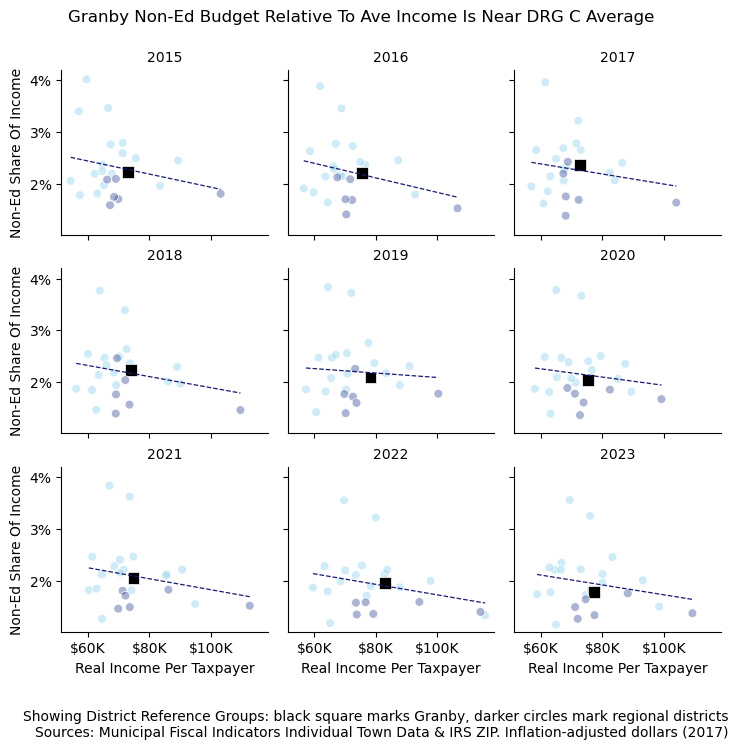

In [24]:
g = sns.relplot(data=district_total_income.rename(columns={'Non-Education Share Of Income': 'Non-Ed Share Of Income'}),
                col='Fiscal Year End', col_wrap=3,
                x='Real Income Per Taxpayer', y='Non-Ed Share Of Income',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Real Income Per Taxpayer', y='Non-Ed Share Of Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.set_ylim(top=.042)
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_k_formatter)
    #plt.xscale('log') 

g.fig.suptitle(f"Granby Non-Ed Budget Relative To Ave Income Is Near {PEERVAL} Average")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Inflation-adjusted dollars (2017)"
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/noned_income_share_v_ave_income.png", dpi=200, metadata=png_metadata)
plt.show()

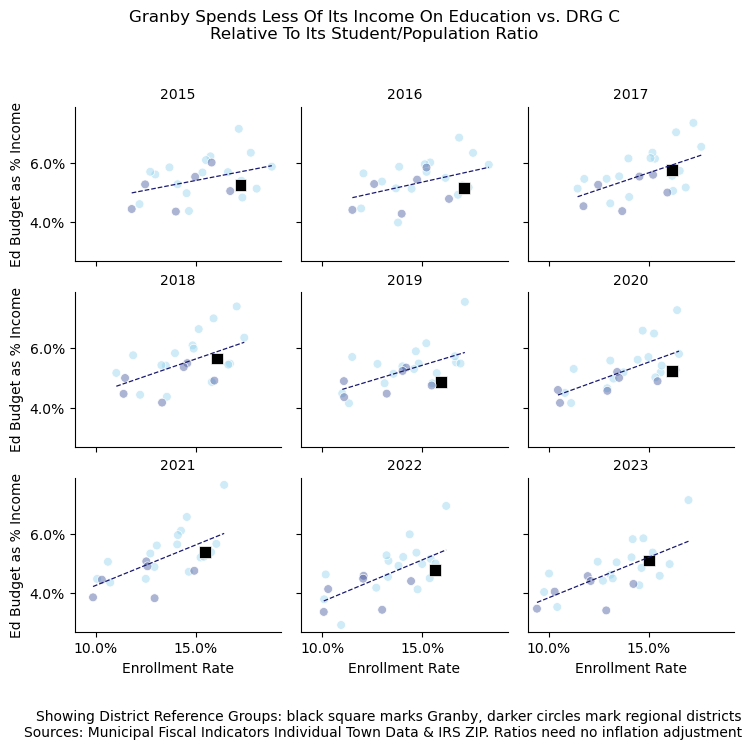

In [25]:
g = sns.relplot(data=district_total_income.rename(columns={'Education Share Of Income': 'Ed Budget as % Income'}),
                col='Fiscal Year End', col_wrap=3,
                x='Enrollment Rate', y='Ed Budget as % Income', 
                height=2.5,  legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")

g.map_dataframe(sns.regplot, x='Enrollment Rate', y='Ed Budget as % Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(perc_formatter)
    ax.yaxis.set_major_formatter(perc_formatter)

g.fig.suptitle(f"Granby Spends Less Of Its Income On Education vs. {PEERVAL}\nRelative To Its Student/Population Ratio")

plt.subplots_adjust(top=.85, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Ratios need no inflation adjustment"
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/ed_income_share_v_studentperc.png", dpi=200, metadata=png_metadata)
plt.show()

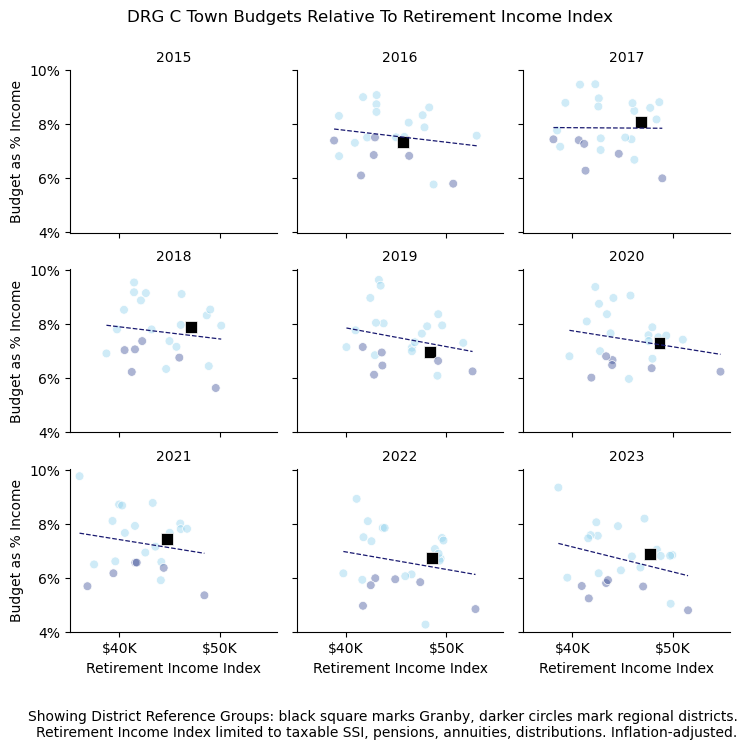

In [26]:
g = sns.relplot(data=district_total_income.rename(columns={'Budget Share Of Income': 'Budget as % Income'}),
                col='Fiscal Year End', col_wrap=3,
                x='Retirement Income Index', y='Budget as % Income',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Retirement Income Index', y='Budget as % Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_k_formatter)
    #plt.xscale('log') 

g.fig.suptitle(f"{PEERVAL} Town Budgets Relative To Retirement Income Index")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts.\n"
line2 = "Retirement Income Index limited to taxable SSI, pensions, annuities, distributions. Inflation-adjusted."
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/budget_income_share_v_retirementindex.png", dpi=200, metadata=png_metadata)

plt.show()

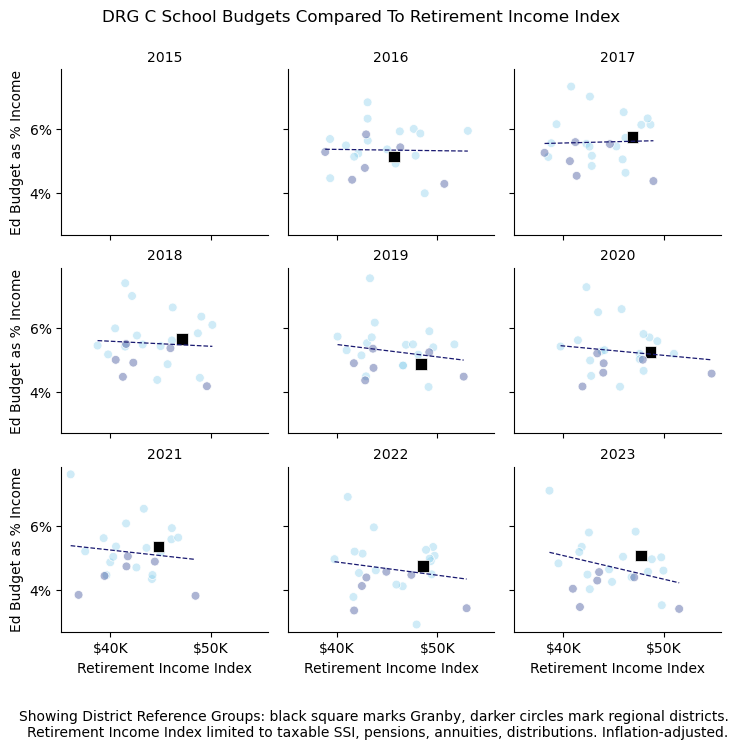

In [27]:
g = sns.relplot(data=district_total_income.rename(columns={'Education Share Of Income': 'Ed Budget as % Income'}),
                col='Fiscal Year End', col_wrap=3,
                x='Retirement Income Index', y='Ed Budget as % Income',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Retirement Income Index', y='Ed Budget as % Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_k_formatter)
    #plt.xscale('log') 

g.fig.suptitle(f"{PEERVAL} School Budgets Compared To Retirement Income Index")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts.\n"
line2 = "Retirement Income Index limited to taxable SSI, pensions, annuities, distributions. Inflation-adjusted."
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/edbudget_income_share_v_retirementindex.png", dpi=200, metadata=png_metadata)

plt.show()

In [28]:
district_total_income[district_total_income['Education Share Of Income'] < .025]

,District,Year,Fiscal Year End,Size of adjusted gross income,Number of returns,Number of single returns,Number of joint returns,Number of head of household returns,Number of exemptions,Number of dependents,...,Flat Tax Per Single Taxpayer,Real Flat Tax Per Taxpayer,Flat Tax Per Taxpayer (2024 dollars),Retirement Income Per Return,Retirement Income Index,Retirement Income Index (2024 dollars),Average School Enrollment,Population,Enrollment Rate,Granby


### Are Retirees 'Getting Squeezed'?

### Income by AGI Band

#### Break out totals & income bands

In [63]:
granby_incomes = town_incomes[(town_incomes['Town'] == 'Granby') &\
                              (town_incomes['Size of adjusted gross income'] != 'Total')].copy()
granby_incomes['Income Band'] = granby_incomes['Income Band'].cat.remove_unused_categories()
granby_incomes['Number of Non-Elderly Returns'] = (granby_incomes['Number of returns']
                                       - granby_incomes['Number of elderly returns'].replace(0, np.nan))
granby_incomes['Elderly Share of Returns'] = granby_incomes['Number of elderly returns'] / granby_incomes['Number of returns']
granby_incomes['ttl_returns'] = granby_incomes.groupby('Year')['Number of returns'].transform('sum')
granby_incomes['Share of Returns'] = granby_incomes['Number of returns'] / granby_incomes['ttl_returns']
granby_incomes['Joint Share of Returns'] = granby_incomes['Number of joint returns'] / granby_incomes['Number of returns']

In [31]:
# % of elderly in each band
ttl_elderly = granby_incomes.groupby('Year')['Number of elderly returns'].sum()
ttl_elderly.name = 'total elderly returns'
ttl_elderly = pd.DataFrame(ttl_elderly).reset_index(drop=False)
granby_incomes = granby_incomes.merge(ttl_elderly, on='Year', how='left')
granby_incomes['Share of Elderly Returns'] = granby_incomes['Number of elderly returns']/granby_incomes['total elderly returns']

In [32]:
# % of non-elderly in each band
ttl_non_elderly = granby_incomes.groupby('Year')['Number of Non-Elderly Returns'].sum()
ttl_non_elderly.name = 'total nonelderly returns'
ttl_non_elderly = pd.DataFrame(ttl_non_elderly).reset_index(drop=False)
granby_incomes = granby_incomes.merge(ttl_non_elderly, on='Year', how='left')
granby_incomes['Share of Non-Elderly Returns'] = granby_incomes['Number of Non-Elderly Returns']/granby_incomes['total nonelderly returns']

### Income Tables
Source: IRS tax information by ZIP
Per taxpayer counts 2 for married filing jointly, 1 for single & head-of-household returns. Each return counts as a household.

#### Per-Household

In [34]:
cap1 = "Average Taxable Income Per Household (Not adjusted for inflation)"
granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Income Per Return')\
              .style.format("${:,.0f}")\
    .set_caption(cap1)\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])

Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000","$10,432","$10,537","$10,427","$10,835","$18,983","$10,910","$11,316","$11,157"
"\$25,000 under \$50,000","$37,734","$37,913","$38,130","$37,539","$37,876","$37,515","$61,142","$37,562"
"\$50,000 under \$75,000","$63,340","$63,639","$63,567","$62,475","$62,101","$62,038","$63,204","$63,370"
"\$75,000 under \$100,000","$89,311","$87,964","$87,808","$88,731","$147,762","$88,294","$151,552","$87,266"
"\$100,000 under \$200,000","$141,841","$143,083","$142,691","$143,412","$143,501","$143,067","$143,900","$144,358"
"\$200,000 or more","$398,595","$371,926","$372,173","$401,149","$376,435","$382,592","$440,093","$411,729"


In [33]:
cap1 = "Average Taxable Income Per Household (Inflation-Adjusted 2024 dollars)"
granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Income Per Return (2024 dollars)')\
              .style.format("${:,.0f}")\
    .set_caption(cap1)\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])

Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000","$13,378","$13,293","$12,926","$13,185","$22,746","$12,900","$12,606","$11,779"
"\$25,000 under \$50,000","$48,390","$47,828","$47,267","$45,682","$45,382","$44,357","$68,111","$39,655"
"\$50,000 under \$75,000","$81,228","$80,282","$78,799","$76,028","$74,409","$73,353","$70,409","$66,900"
"\$75,000 under \$100,000","$114,534","$110,967","$108,848","$107,978","$177,047","$104,399","$168,827","$92,128"
"\$100,000 under \$200,000","$181,898","$180,501","$176,882","$174,521","$171,940","$169,163","$160,302","$152,400"
"\$200,000 or more","$511,165","$469,188","$461,351","$488,166","$451,038","$452,379","$490,256","$434,666"


#### Per Taxpayer
**\\$100K-\$200K Per-Taxpayer Income starts looking "low" because a lot more returns are filed jointly**

In [35]:
cap1 = "Average Taxable Income Per Taxpayer (Inflation-Adjusted 2024 dollars)"
granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Income Per Taxpayer (2024 dollars)')\
              .style.format("${:,.0f}")\
    .set_caption(cap1)\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])

Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000","$12,474","$12,370","$12,171","$12,286","$21,502","$12,081","$11,936","$10,797"
"\$25,000 under \$50,000","$38,095","$37,759","$37,102","$37,561","$36,873","$36,013","$56,050","$33,554"
"\$50,000 under \$75,000","$59,852","$60,211","$59,955","$58,943","$58,577","$58,683","$57,460","$54,953"
"\$75,000 under \$100,000","$71,292","$69,784","$70,298","$70,470","$118,031","$69,958","$119,280","$65,805"
"\$100,000 under \$200,000","$99,280","$98,273","$97,021","$95,726","$94,886","$94,881","$90,427","$87,796"
"\$200,000 or more","$265,645","$242,042","$239,094","$252,165","$231,302","$235,118","$260,362","$228,893"


In [35]:
cap1 = "Average Taxable Income Per Taxpayer (Inflation-Adjusted 2024 dollars)"
granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Disposable Income Per Taxpayer (2024 dollars)')\
              .style.format("${:,.0f}")\
    .set_caption(cap1)\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])

Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000","$12,474","$12,370","$12,171","$12,286","$21,502","$12,081","$11,936","$10,797"
"\$25,000 under \$50,000","$38,095","$37,759","$37,102","$37,561","$36,873","$36,013","$56,050","$33,554"
"\$50,000 under \$75,000","$59,852","$60,211","$59,955","$58,943","$58,577","$58,683","$57,460","$54,953"
"\$75,000 under \$100,000","$71,292","$69,784","$70,298","$70,470","$118,031","$69,958","$119,280","$65,805"
"\$100,000 under \$200,000","$99,280","$98,273","$97,021","$95,726","$94,886","$94,881","$90,427","$87,796"
"\$200,000 or more","$265,645","$242,042","$239,094","$252,165","$231,302","$235,118","$260,362","$228,893"


#### Household Counts

In [36]:
#  returns in each band
_dist = granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Number of returns')
_dist.style.format("{:,.0f}").set_caption('Number of Tax Returns In Each Band')\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])


Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000","1,380","1,340","1,290","1,230","1,210","1,180","1,070","1,100"
"\$25,000 under \$50,000",740,750,730,740,780,820,790,770
"\$50,000 under \$75,000",700,660,700,690,740,800,710,690
"\$75,000 under \$100,000",610,610,620,620,640,650,650,650
"\$100,000 under \$200,000","1,430","1,470","1,470","1,470","1,490","1,520","1,540","1,590"
"\$200,000 or more",660,650,710,780,800,790,940,990


In [62]:
#  returns in each band
_dist = granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Share of Returns')
_dist.style.format("{:,.1%}").set_caption('Share Of Tax Returns In Each Band<br>(columns sum to 100%)')\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])


Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000",25.0%,24.5%,23.4%,22.2%,21.4%,20.5%,18.8%,19.0%
"\$25,000 under \$50,000",13.4%,13.7%,13.2%,13.4%,13.8%,14.2%,13.9%,13.3%
"\$50,000 under \$75,000",12.7%,12.0%,12.7%,12.5%,13.1%,13.9%,12.5%,11.9%
"\$75,000 under \$100,000",11.1%,11.1%,11.2%,11.2%,11.3%,11.3%,11.4%,11.2%
"\$100,000 under \$200,000",25.9%,26.8%,26.6%,26.6%,26.3%,26.4%,27.0%,27.5%
"\$200,000 or more",12.0%,11.9%,12.9%,14.1%,14.1%,13.7%,16.5%,17.1%


In [64]:
#  returns in each band
_dist = granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Joint Share of Returns')
_dist.style.format("{:,.1%}").set_caption('Share Of Tax Returns In Each Band That Are Filed Jointly')\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])


Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000",7.2%,7.5%,6.2%,7.3%,5.8%,6.8%,5.6%,9.1%
"\$25,000 under \$50,000",27.0%,26.7%,27.4%,21.6%,23.1%,23.2%,21.5%,18.2%
"\$50,000 under \$75,000",35.7%,33.3%,31.4%,29.0%,27.0%,25.0%,22.5%,21.7%
"\$75,000 under \$100,000",60.7%,59.0%,54.8%,53.2%,50.0%,49.2%,41.5%,40.0%
"\$100,000 under \$200,000",83.2%,83.7%,82.3%,82.3%,81.2%,78.3%,77.3%,73.6%
"\$200,000 or more",92.4%,93.8%,93.0%,93.6%,95.0%,92.4%,88.3%,89.9%


### Retirement Income

Retirement Income is divided by what the IRS calls "elderly returns."

**Obviously not showing all income because the average income in each row should be above the bottom of the AGI band.** 

In [37]:
cap1 = "Taxable Retirement Account Distributions, Pensions, Annuities, Soc. Security Per 65+ Household<br>"
cap2 = "Excludes Non-Taxable Income, All Dividend & Interest (Not Adjusted For Inflation)"
granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Retirement Income Per Return')\
              .style.format("${:,.0f}")\
    .set_caption(cap1 + cap2)\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])

Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000","$9,207","$8,742","$11,329","$9,447","$10,214","$8,878","$6,821","$8,619"
"\$25,000 under \$50,000","$23,560","$28,627","$23,365","$25,577","$22,796","$23,507","$28,517","$24,692"
"\$50,000 under \$75,000","$44,812","$43,179","$36,941","$37,892","$48,887","$47,459","$38,983","$44,377"
"\$75,000 under \$100,000","$47,524","$44,008","$49,067","$49,688","$46,526","$45,841","$53,816","$54,822"
"\$100,000 under \$200,000","$66,958","$68,832","$73,470","$69,809","$68,698","$69,082","$74,202","$75,898"
"\$200,000 or more","$73,219","$84,353","$72,229","$87,216","$91,564","$79,548","$91,994","$102,066"


In [38]:
cap1 = "Taxable Retirement Account Distributions, Pensions, Annuities, Soc. Security Per 65+ Household<br>"
cap2 = "Excludes Non-Taxable Income, All Dividend & Interest (Inflation-Adjusted 2024 Dollars)"
granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Retirement Income Index (2024 dollars)')\
              .style.format("${:,.0f}")\
    .set_caption(cap1 + cap2)\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])

Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000","$11,807","$11,028","$14,043","$11,496","$12,238","$10,498","$7,598","$9,099"
"\$25,000 under \$50,000","$30,214","$36,114","$28,964","$31,126","$27,314","$27,795","$31,768","$26,068"
"\$50,000 under \$75,000","$57,468","$54,471","$45,792","$46,112","$58,576","$56,116","$43,426","$46,849"
"\$75,000 under \$100,000","$60,945","$55,517","$60,824","$60,466","$55,747","$54,202","$59,950","$57,876"
"\$100,000 under \$200,000","$85,868","$86,832","$91,074","$84,952","$82,313","$81,683","$82,659","$80,127"
"\$200,000 or more","$93,897","$106,412","$89,535","$106,135","$109,711","$94,058","$102,480","$107,752"


#### Number & share of returns by income band

In [39]:
# % of elderly returns in each band
# each column sums to 100%
# For the last two reported years, over 46% of elderly returns were in $100K and up 
eld_dist = granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Number of elderly returns')
eld_dist.style.format("{:,.0f}").set_caption('Number of 65+ Returns In Each Band')\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])


Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000",290,310,280,300,290,320,290,320
"\$25,000 under \$50,000",250,220,230,220,260,290,230,260
"\$50,000 under \$75,000",240,240,270,260,230,270,290,260
"\$75,000 under \$100,000",250,250,240,240,270,270,250,270
"\$100,000 under \$200,000",450,470,500,550,580,560,610,650
"\$200,000 or more",160,170,210,250,250,230,330,320


In [40]:
# % of elderly returns in each band
# each column sums to 100%
# For the last two reported years, over 46% of elderly returns were in $100K and up 
eld_dist = granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Number of Non-Elderly Returns')
eld_dist.style.format("{:,.0f}").set_caption('Number of Non-Retired Returns In Each Band')\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])


Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000","1,090","1,030","1,010",930,920,860,780,780
"\$25,000 under \$50,000",490,530,500,520,520,530,560,510
"\$50,000 under \$75,000",460,420,430,430,510,530,420,430
"\$75,000 under \$100,000",360,360,380,380,370,380,400,380
"\$100,000 under \$200,000",980,"1,000",970,920,910,960,930,940
"\$200,000 or more",500,480,500,530,550,560,610,670


In [41]:
# % of returns in each band
# each column sums to 100%
# For the last two reported years, over 46% of elderly returns were in $100K and up 
eld_dist = granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Share of Elderly Returns')
eld_dist.style.format("{:.1%}").set_caption('% of 65+ Returns In Each Band<br>(column sums to 100% of 65+ returns)')\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])


Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000",17.7%,18.7%,16.2%,16.5%,15.4%,16.5%,14.5%,15.4%
"\$25,000 under \$50,000",15.2%,13.3%,13.3%,12.1%,13.8%,14.9%,11.5%,12.5%
"\$50,000 under \$75,000",14.6%,14.5%,15.6%,14.3%,12.2%,13.9%,14.5%,12.5%
"\$75,000 under \$100,000",15.2%,15.1%,13.9%,13.2%,14.4%,13.9%,12.5%,13.0%
"\$100,000 under \$200,000",27.4%,28.3%,28.9%,30.2%,30.9%,28.9%,30.5%,31.2%
"\$200,000 or more",9.8%,10.2%,12.1%,13.7%,13.3%,11.9%,16.5%,15.4%


In [42]:
# % of elderly returns in each band
# each column sums to 100%
# For the last two reported years, over 46% of elderly returns were in $100K and up 
eld_dist = granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Share of Elderly Returns')
eld_dist.style.format("{:.1%}").set_caption('% of 65+ Returns In Each Band<br>(column sums to 100% of 65+ returns)')\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])


Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000",17.7%,18.7%,16.2%,16.5%,15.4%,16.5%,14.5%,15.4%
"\$25,000 under \$50,000",15.2%,13.3%,13.3%,12.1%,13.8%,14.9%,11.5%,12.5%
"\$50,000 under \$75,000",14.6%,14.5%,15.6%,14.3%,12.2%,13.9%,14.5%,12.5%
"\$75,000 under \$100,000",15.2%,15.1%,13.9%,13.2%,14.4%,13.9%,12.5%,13.0%
"\$100,000 under \$200,000",27.4%,28.3%,28.9%,30.2%,30.9%,28.9%,30.5%,31.2%
"\$200,000 or more",9.8%,10.2%,12.1%,13.7%,13.3%,11.9%,16.5%,15.4%


In [43]:
# % of elderly returns in each band
# For the last two reported years, over 46% of elderly returns were in $100K and up 
eld_dist.sort_index(ascending=False).cumsum(axis=0).sort_index(ascending=True)\
         .style.format("{:.1%}")\
        .set_caption('Cumulative % of Elderly Returns In Or Above Each Band<br>(59.6% of 2022 elderly returns have AGI $75K or more)')\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])


Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000",100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%
"\$25,000 under \$50,000",82.3%,81.3%,83.8%,83.5%,84.6%,83.5%,85.5%,84.6%
"\$50,000 under \$75,000",67.1%,68.1%,70.5%,71.4%,70.7%,68.6%,74.0%,72.1%
"\$75,000 under \$100,000",52.4%,53.6%,54.9%,57.1%,58.5%,54.6%,59.5%,59.6%
"\$100,000 under \$200,000",37.2%,38.6%,41.0%,44.0%,44.1%,40.7%,47.0%,46.6%
"\$200,000 or more",9.8%,10.2%,12.1%,13.7%,13.3%,11.9%,16.5%,15.4%


#### Compare to Non-Retirees

In [44]:
# % of returns in each band
# each column sums to 100%
noneld_dist = granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Share of Non-Elderly Returns')
noneld_dist.style.format("{:.1%}").set_caption('% of Non-Retired Returns In Each Band<br>(column sums to 100% of non-retired returns)')\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])

Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000",28.1%,27.0%,26.6%,25.1%,24.3%,22.5%,21.1%,21.0%
"\$25,000 under \$50,000",12.6%,13.9%,13.2%,14.0%,13.8%,13.9%,15.1%,13.7%
"\$50,000 under \$75,000",11.9%,11.0%,11.3%,11.6%,13.5%,13.9%,11.4%,11.6%
"\$75,000 under \$100,000",9.3%,9.4%,10.0%,10.2%,9.8%,9.9%,10.8%,10.2%
"\$100,000 under \$200,000",25.3%,26.2%,25.6%,24.8%,24.1%,25.1%,25.1%,25.3%
"\$200,000 or more",12.9%,12.6%,13.2%,14.3%,14.6%,14.7%,16.5%,18.1%


In [45]:
# % of returns in or above each band
noneld_dist.sort_index(ascending=False).cumsum(axis=0).sort_index(ascending=True)\
    .style.format("{:.1%}")\
    .set_caption('% of Non-Elderly Returns In or Above Each Band<br>(53.6% of 2022 returns have AGI $75K or more)')\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])

Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000",100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%
"\$25,000 under \$50,000",71.9%,73.0%,73.4%,74.9%,75.7%,77.5%,78.9%,79.0%
"\$50,000 under \$75,000",59.3%,59.2%,60.2%,60.9%,61.9%,63.6%,63.8%,65.2%
"\$75,000 under \$100,000",47.4%,48.2%,48.8%,49.3%,48.4%,49.7%,52.4%,53.6%
"\$100,000 under \$200,000",38.1%,38.7%,38.8%,39.1%,38.6%,39.8%,41.6%,43.4%
"\$200,000 or more",12.9%,12.6%,13.2%,14.3%,14.6%,14.7%,16.5%,18.1%


In [46]:
# % of returns in each band that are elderly returns
granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Elderly Share of Returns')\
              .style.format("{:.1%}")\
    .set_caption('% of Elderly Returns In Each Band')\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])

Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000",21.0%,23.1%,21.7%,24.4%,24.0%,27.1%,27.1%,29.1%
"\$25,000 under \$50,000",33.8%,29.3%,31.5%,29.7%,33.3%,35.4%,29.1%,33.8%
"\$50,000 under \$75,000",34.3%,36.4%,38.6%,37.7%,31.1%,33.8%,40.8%,37.7%
"\$75,000 under \$100,000",41.0%,41.0%,38.7%,38.7%,42.2%,41.5%,38.5%,41.5%
"\$100,000 under \$200,000",31.5%,32.0%,34.0%,37.4%,38.9%,36.8%,39.6%,40.9%
"\$200,000 or more",24.2%,26.2%,29.6%,32.1%,31.2%,29.1%,35.1%,32.3%


In [47]:
town_ssi.query('Town == "Granby"')[['Year', 'Recipients', 'Retired', 'Recipients 65+', 'Annual SSI (Retired)',
                                    'Real Annual SSI (Retired)', '2011 SSI + COLA (Retired)', 'Real 2011 SSI w/o COLA (Retired)']]\
        .style.format({x: "{:,.0f}" for x in ['Recipients', 'Retired', 'Recipients 65+']} | 
                      {x: "${:,.0f}" for x in ['Annual SSI (Retired)', '2011 SSI + COLA (Retired)', 'Real Annual SSI (Retired)', 'Real 2011 SSI w/o COLA (Retired)']})

,Year,Recipients,Retired,Recipients 65+,Annual SSI (Retired),Real Annual SSI (Retired),2011 SSI + COLA (Retired),Real 2011 SSI w/o COLA (Retired)
715,2011,"1,875","1,425","1,525","$17,204","$18,386","$17,204","$18,386"
716,2012,"1,930","1,475","1,575","$17,719","$18,633","$17,824","$18,092"
717,2013,"1,980","1,535","1,650","$18,246","$18,925","$18,127","$17,844"
718,2014,"1,990","1,550","1,665","$18,782","$19,339","$18,398","$17,714"
719,2015,"2,005","1,550","1,690","$18,937","$19,431","$18,711","$17,653"
720,2016,"2,045","1,585","1,725","$19,329","$19,510","$18,711","$17,366"
721,2017,"2,095","1,635","1,780","$20,037","$19,874","$18,767","$17,064"
722,2018,"2,145","1,710","1,830","$20,926","$20,376","$19,143","$16,752"
723,2019,"2,240","1,775","1,925","$21,431","$20,546","$19,679","$16,494"
724,2020,"2,335","1,885","2,030","$22,173","$20,977","$19,994","$16,277"


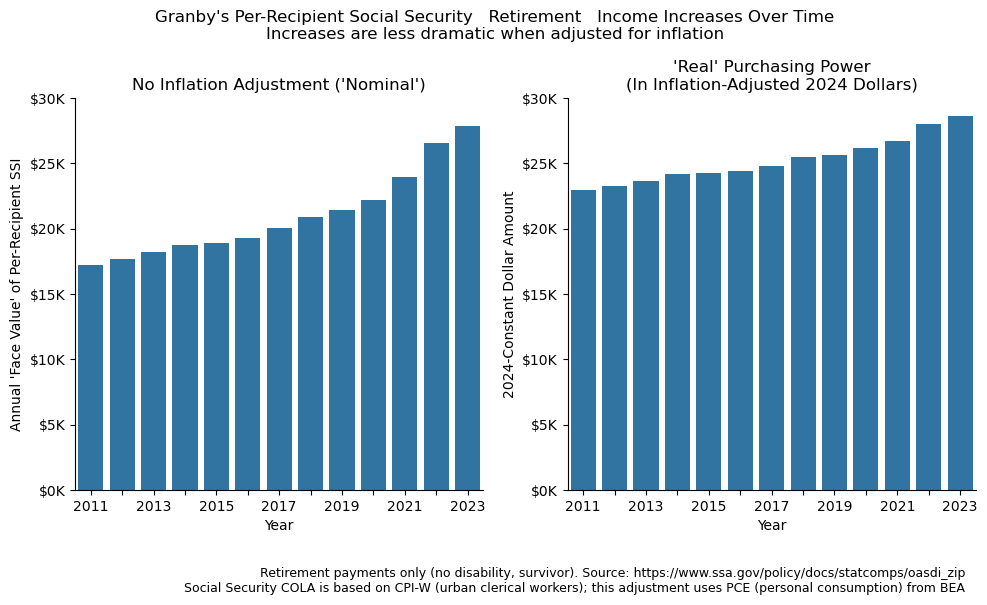

In [48]:
fig, axs = plt.subplots(1, 2, figsize=(10,6))

line1 = "Granby's Per-Recipient Social Security   Retirement   Income Increases Over Time\n"
line2 = "Increases are less dramatic when adjusted for inflation"
fig.suptitle(line1 + line2)

sns.barplot(town_ssi.query('Town == "Granby"'), x='Year', y='Annual SSI (Retired)',
                 ax = axs[0])
axs[0].set_title("No Inflation Adjustment ('Nominal')")
axs[0].set_ylabel("Annual 'Face Value' of Per-Recipient SSI")


sns.barplot(town_ssi.query('Town == "Granby"'), x='Year', y='Retirement SSI (2024 dollars)',
                 ax = axs[1])
axs[1].set_title("'Real' Purchasing Power\n(In Inflation-Adjusted 2024 Dollars)")
axs[1].set_ylabel("2024-Constant Dollar Amount")

for ax in axs:
    ax.set_ylim(0,30000)
    ax.yaxis.set_major_formatter(dollar_k_formatter)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0: # Check if the index is odd (for every other)
            label.set_visible(False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

line1 = "Retirement payments only (no disability, survivor). Source: https://www.ssa.gov/policy/docs/statcomps/oasdi_zip\n"
line2 = "Social Security COLA is based on CPI-W (urban clerical workers); this adjustment uses PCE (personal consumption) from BEA"
fig.text(.97, 0.01, line1 + line2, fontsize=9, ha='right')

sns.despine()
plt.savefig("./charts/social_security/ssi_real_retirement_increase.png", dpi=200, metadata=png_metadata)

plt.show()

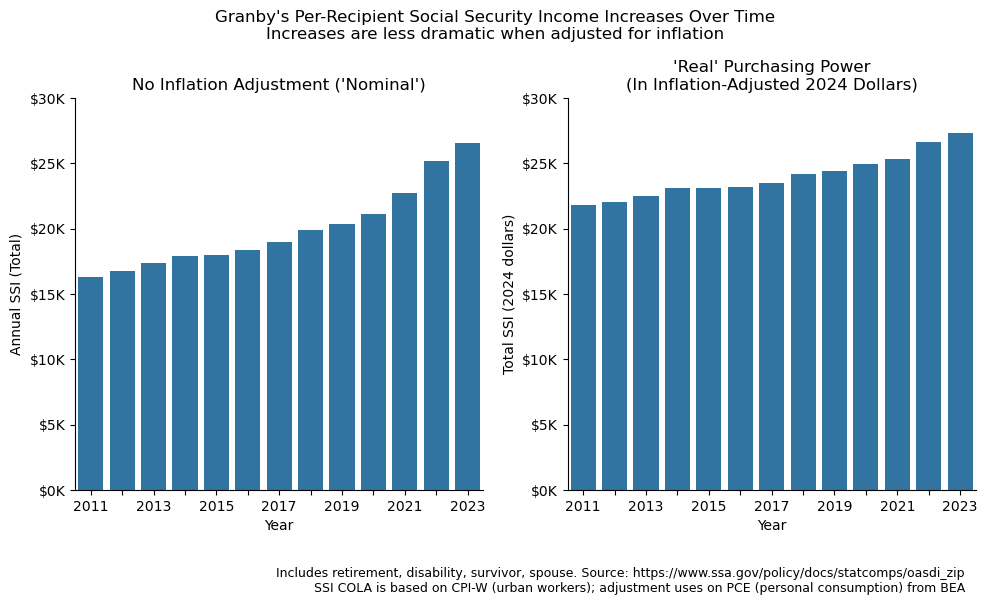

In [49]:
fig, axs = plt.subplots(1, 2, figsize=(10,6))

line1 = "Granby's Per-Recipient Social Security Income Increases Over Time\n"
line2 = "Increases are less dramatic when adjusted for inflation"
fig.suptitle(line1 + line2)

sns.barplot(town_ssi.query('Town == "Granby"'), x='Year', y='Annual SSI (Total)',
                 ax = axs[0])
axs[0].set_title("No Inflation Adjustment ('Nominal')")


sns.barplot(town_ssi.query('Town == "Granby"'), x='Year', y='Total SSI (2024 dollars)',
                 ax = axs[1])
axs[1].set_title("'Real' Purchasing Power\n(In Inflation-Adjusted 2024 Dollars)")

for ax in axs:
    ax.set_ylim(0,30000)
    ax.yaxis.set_major_formatter(dollar_k_formatter)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0: # Check if the index is odd (for every other)
            label.set_visible(False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

line1 = "Includes retirement, disability, survivor, spouse. Source: https://www.ssa.gov/policy/docs/statcomps/oasdi_zip\n"
line2 = "SSI COLA is based on CPI-W (urban workers); adjustment uses on PCE (personal consumption) from BEA"

fig.text(.97, 0.01, line1 + line2, fontsize=9, ha='right')
sns.despine()

plt.savefig("./charts/social_security/ssi_real_increase.png", dpi=200, metadata=png_metadata)

plt.show()

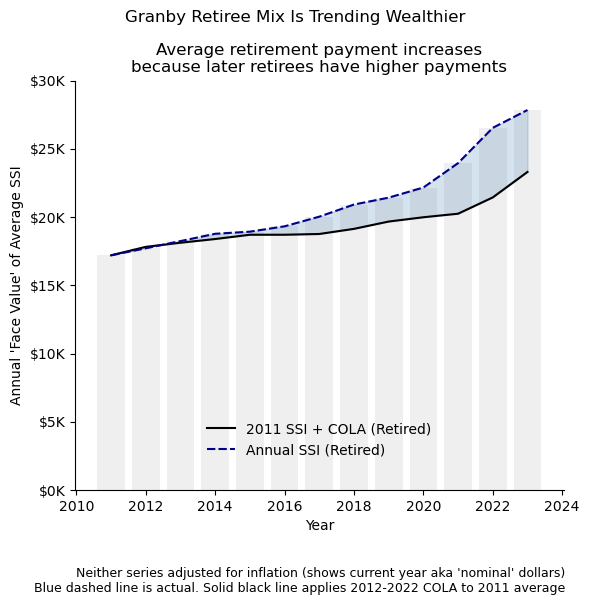

In [50]:
_df = town_ssi.query('Town == "Granby"').melt(id_vars=["Year"], var_name="Income",
                                              value_vars= ['2011 SSI + COLA (Retired)',
                                                           'Real 2011 SSI + COLA (Retired)',
                                                           'Real Annual SSI (Retired)',
                                                           'Real 2011 SSI w/o COLA (Retired)',
                                                           'Annual SSI (Retired)']
                                            )

fig, ax = plt.subplots(1, 1, figsize=(6,6),)
fig.suptitle("Granby Retiree Mix Is Trending Wealthier")

ax.bar(town_ssi.query('Town == "Granby"')['Year'], town_ssi.query('Town == "Granby"')['Annual SSI (Retired)'],
           color='lightgray', alpha=.35)

sns.lineplot(_df.query('~Income.str.startswith("Real")'), x='Year', y='value',
             hue='Income', palette=['black', 'darkblue'], 
             style='Income', 
              ax = ax)

ax.fill_between(town_ssi.query('Town == "Granby"').Year,
                    town_ssi.query('Town == "Granby"')['Annual SSI (Retired)'],
                    town_ssi.query('Town == "Granby"')['2011 SSI + COLA (Retired)'],color='steelblue', alpha=0.225)

sns.despine()
sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, .05), frameon=False, title='')
ax.set_title("Average retirement payment increases\nbecause later retirees have higher payments")
ax.set_ylabel("Annual 'Face Value' of Average SSI")
ax.set_ylim(0,30000)
ax.yaxis.set_major_formatter(dollar_k_formatter)


plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

line1 = "Neither series adjusted for inflation (shows current year aka 'nominal' dollars)\n"
line2 = "Blue dashed line is actual. Solid black line applies 2012-2022 COLA to 2011 average"
fig.text(.95, .01, line1 + line2, fontsize=9, ha='right')

plt.savefig("./charts/social_security/ssi_mix_changes.png", dpi=200, metadata=png_metadata)

plt.show()

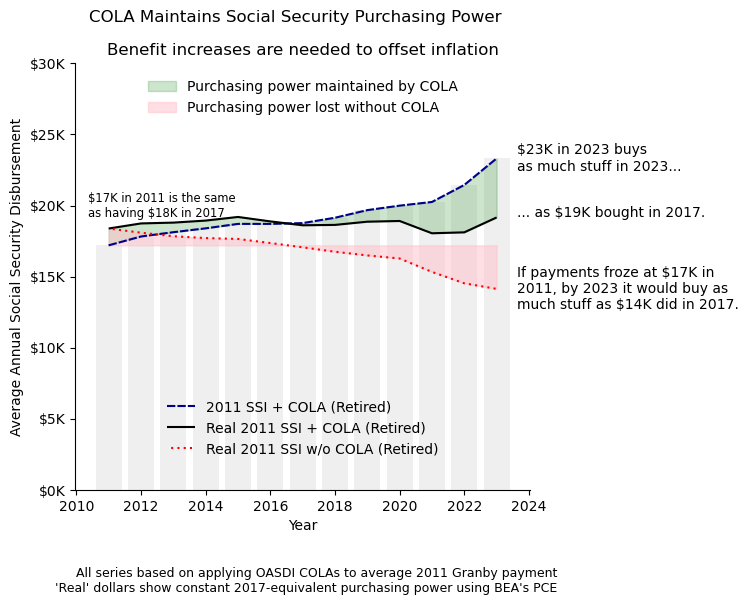

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(7.5,6),)

fig.suptitle("COLA Maintains Social Security Purchasing Power", x=.4)
ax.set_title("Benefit increases are needed to offset inflation")

_tssi = town_ssi.query('Town == "Granby"')
ax.bar(_tssi['Year'],
       _tssi['2011 SSI + COLA (Retired)'],
           color='lightgray', alpha=.35)

sns.lineplot(_df.query('Income.str.find("COLA") > 0'), x='Year', y='value',
             hue='Income', palette=[ 'darkblue', 'black', 'red'],
             style='Income',  dashes=[(4, 1), (1, 0), (0, 2, 1, 0)],
             ax = ax)

ax.add_artist(ax.legend(loc="lower center", bbox_to_anchor=(.5, .05), frameon=False, title=''))
#sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, .05), frameon=False, title='')
ax.set_ylabel("Value")

ul = ax.fill_between(_tssi.Year,
                    _tssi['2011 SSI + COLA (Retired)'],
                    _tssi['Real 2011 SSI + COLA (Retired)'],color='forestgreen',
                    alpha=0.225, label='Purchasing power maintained by COLA')

ll = ax.fill_between(_tssi.Year,
                    _tssi['Annual SSI 2011 (Retired)'],
                    _tssi['Real 2011 SSI w/o COLA (Retired)'],
                     color='pink', alpha=0.5,
                    label='Purchasing power lost without COLA'
                   )

_amt2011 = _tssi['Annual SSI 2011 (Retired)'].mean()
_ramt2011 = _tssi[_tssi.Year == _tssi.Year.min()]['Real 2011 SSI w/o COLA (Retired)'].item()
lina = "$17K in 2011 is the same\n"
linb = f"as having ${_ramt2011/1000:.0f}K in 2017"
ax.annotate(lina + linb, 
            (_tssi.Year.min(), _amt2011),
            xytext=(-15,18), textcoords='offset points', va='bottom', ha='left',
            fontsize='small')

_toploc = _tssi[_tssi.Year == _tssi.Year.max()]['2011 SSI + COLA (Retired)'].item()
ax.annotate(f"${_toploc/1000:.0f}K in {_tssi.Year.max()} buys\nas much stuff in {_tssi.Year.max()}...", 
            (_tssi.Year.max(), _toploc),
            xytext=(15,0), textcoords='offset points', va='center', ha='left')

_midloc = _tssi[_tssi.Year == _tssi.Year.max()]['Real 2011 SSI + COLA (Retired)'].item()
ax.annotate(f"... as ${_midloc/1000:.0f}K bought in 2017.",  
            (_tssi.Year.max(), _midloc), 
            xytext=(15,0), textcoords='offset points')

_botloc = _tssi[_tssi.Year == _tssi.Year.max()]['Real 2011 SSI w/o COLA (Retired)'].item()
_botstart = _tssi[_tssi.Year == _tssi.Year.min()]['2011 SSI + COLA (Retired)'].item()
line1 = f"If payments froze at ${_botstart/1000:,.0f}K in\n"
line2 = f"{_tssi.Year.min()}, by {_tssi.Year.max()} it would buy as\n"
line3 = f"much stuff as ${_botloc/1000:.0f}K did in 2017."
ax.annotate(line1 + line2 + line3, 
            (_tssi.Year.max(), _botloc), 
            xytext=(15,0), textcoords='offset points', va='center')

ax.legend(handles=[ul, ll],loc="upper center", bbox_to_anchor=(.5, .99), frameon=False, title='')

ax.set_ylim(0,30000)
ax.yaxis.set_major_formatter(dollar_k_formatter)
ax.set_ylabel('Average Annual Social Security Disbursement')


plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

line1 = "All series based on applying OASDI COLAs to average 2011 Granby payment\n"
line2 = "'Real' dollars show constant 2017-equivalent purchasing power using BEA's PCE"
fig.text(.75, 0.01, line1 + line2, fontsize=9, ha='right')
sns.despine()

plt.savefig("./charts/social_security/ssi_inflation_effect.png", dpi=200, metadata=png_metadata)

plt.show()

#### Retirement Income Index
This is only an index useful for comparison.

Average taxable SSI, Pensions, Annuities, Retirement Acccount distributions per "Elderly" return. 

This understates retiree income. First, it excludes other sources of taxable income, non-taxable distributions or interest, or taxable dividends or interest because those are not reported separately by the IRS. Second, because the number of elderly returns used as the denominator is larger than the number of returns reporting taxable pensions, annuities, and distributions, the resulting average is likely underestimated.

In [52]:
town_total_income.query('Town == "Granby"')[['Year', 'Number of returns', 'Number of elderly returns', 'Retirement Income Index']]\
    .style.format({'Number of returns':"{:,.0f}", 'Number of elderly returns':"{:,.0f}",'Retirement Income Index':"${:,.0f}"})

,Year,Number of returns,Number of elderly returns,Retirement Income Index
4248,2013,"5,520",0,$nan
4255,2014,"5,480",0,$nan
4262,2015,"5,520","1,640","$45,700"
4269,2016,"5,480","1,660","$46,859"
4276,2017,"5,520","1,730","$47,127"
4283,2018,"5,530","1,820","$48,384"
4290,2019,"5,660","1,880","$48,665"
4297,2020,"5,760","1,940","$44,783"
4304,2021,"5,700","2,000","$48,541"
4311,2022,"5,790","2,080","$47,723"


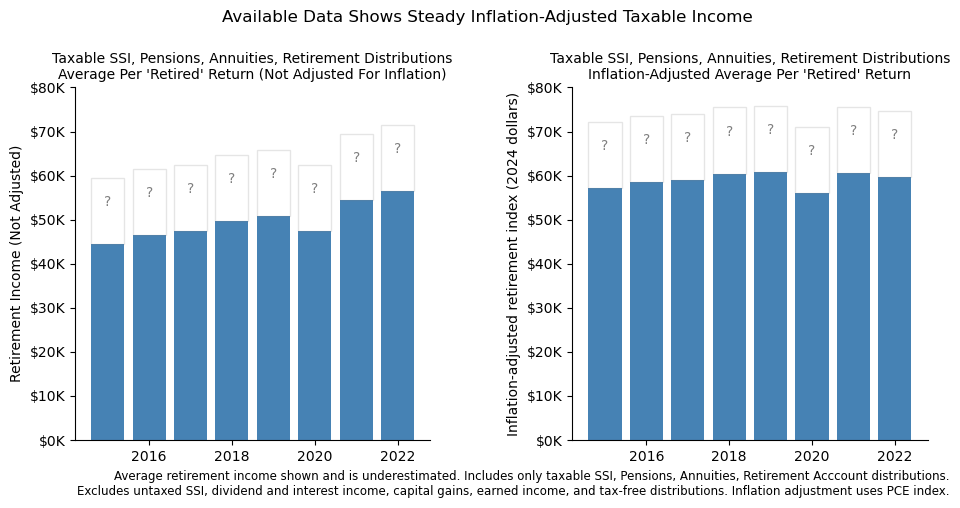

In [53]:

_df = town_total_income[town_total_income['Number of elderly returns'] > 0].query('Town == "Granby"')


fig, axs = plt.subplots(1, 2, figsize=(11,5), gridspec_kw={'wspace':.4})

fig.suptitle("Available Data Shows Steady Inflation-Adjusted Taxable Income")

# left side
ax = axs[0]

bars = ax.bar(_df['Year'],
       _df['Retirement Income Per Return'],
       facecolor='steelblue', )

for bar in bars:
    height = bar.get_height() + 7000
    ax.annotate("?",
                xy=(bar.get_x() + bar.get_width() / 2, height), #
                xytext=(0, 3), # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', color='gray')

ax.bar(_df['Year'],
       _df.shape[0]*[15000],
       bottom=_df['Retirement Income Per Return'],
       edgecolor='gray', facecolor='none', alpha=.2)
sns.despine()

ax.set_ylabel("Retirement Income (Not Adjusted)")
ax.yaxis.set_major_formatter(dollar_k_formatter)
ax.set_ylim(top=80000)

ax.set_title("Taxable SSI, Pensions, Annuities, Retirement Distributions\nAverage Per 'Retired' Return (Not Adjusted For Inflation)",
            fontsize=10)


# right side
ax = axs[1]

ax.set_title("Taxable SSI, Pensions, Annuities, Retirement Distributions\nInflation-Adjusted Average Per 'Retired' Return",
            fontsize=10)

_df = town_total_income[town_total_income['Number of elderly returns'] > 0].query('Town == "Granby"')

bars = ax.bar(_df['Year'],
       _df['Retirement Income Index (2024 dollars)'],
       facecolor='steelblue', )

for bar in bars:
    height = bar.get_height() + 7000
    ax.annotate("?",
                xy=(bar.get_x() + bar.get_width() / 2, height), #
                xytext=(0, 3), # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', color='gray')

ax.bar(_df['Year'],
       _df.shape[0]*[15000],
       bottom=_df['Retirement Income Index (2024 dollars)'],
       edgecolor='gray', facecolor='none', alpha=.2)
sns.despine()

ax.set_ylabel("Inflation-adjusted retirement index (2024 dollars)")
ax.yaxis.set_major_formatter(dollar_k_formatter)
ax.set_ylim(top=80000)

plt.subplots_adjust(top=.825, bottom=0.12)

line1 = "Average retirement income shown and is underestimated. Includes only taxable SSI, Pensions, Annuities, Retirement Acccount distributions."
line2 = "\nExcludes untaxed SSI, "
line3 = "dividend and interest income, capital gains, earned income, and tax-free distributions. Inflation adjustment uses PCE index."
fig.text(.92, .01, line1 + line2 + line3, ha='right', fontsize=8.5)

plt.savefig(f"./charts/social_security/real_retirement_index.png", dpi=200, metadata=png_metadata)

plt.show()

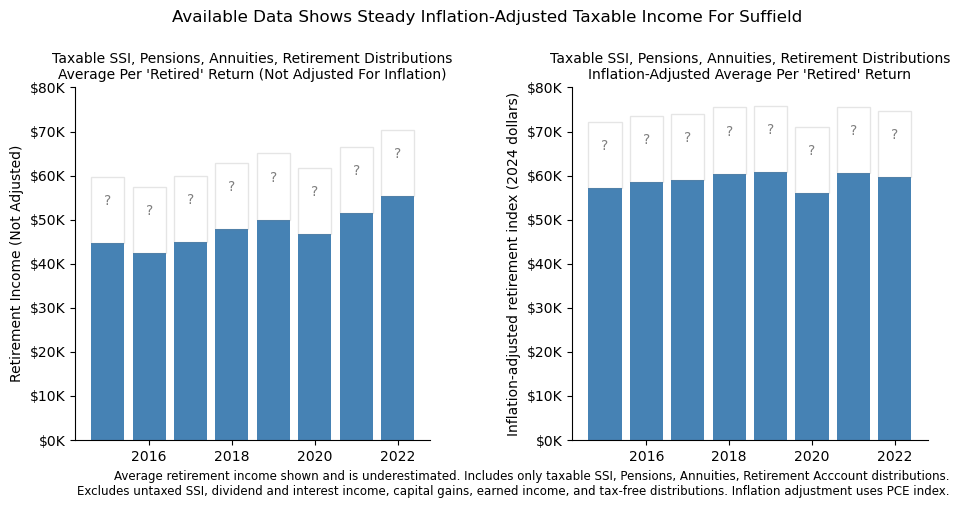

In [54]:

_df = town_total_income[town_total_income['Number of elderly returns'] > 0].query('Town == "Suffield"')


fig, axs = plt.subplots(1, 2, figsize=(11,5), gridspec_kw={'wspace':.4})

fig.suptitle("Available Data Shows Steady Inflation-Adjusted Taxable Income For Suffield")

# left side
ax = axs[0]

bars = ax.bar(_df['Year'],
       _df['Retirement Income Per Return'],
       facecolor='steelblue', )

for bar in bars:
    height = bar.get_height() + 7000
    ax.annotate("?",
                xy=(bar.get_x() + bar.get_width() / 2, height), #
                xytext=(0, 3), # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', color='gray')

ax.bar(_df['Year'],
       _df.shape[0]*[15000],
       bottom=_df['Retirement Income Per Return'],
       edgecolor='gray', facecolor='none', alpha=.2)
sns.despine()

ax.set_ylabel("Retirement Income (Not Adjusted)")
ax.yaxis.set_major_formatter(dollar_k_formatter)
ax.set_ylim(top=80000)

ax.set_title("Taxable SSI, Pensions, Annuities, Retirement Distributions\nAverage Per 'Retired' Return (Not Adjusted For Inflation)",
            fontsize=10)


# right side
ax = axs[1]

ax.set_title("Taxable SSI, Pensions, Annuities, Retirement Distributions\nInflation-Adjusted Average Per 'Retired' Return",
            fontsize=10)

_df = town_total_income[town_total_income['Number of elderly returns'] > 0].query('Town == "Granby"')

bars = ax.bar(_df['Year'],
       _df['Retirement Income Index (2024 dollars)'],
       facecolor='steelblue', )

for bar in bars:
    height = bar.get_height() + 7000
    ax.annotate("?",
                xy=(bar.get_x() + bar.get_width() / 2, height), #
                xytext=(0, 3), # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', color='gray')

ax.bar(_df['Year'],
       _df.shape[0]*[15000],
       bottom=_df['Retirement Income Index (2024 dollars)'],
       edgecolor='gray', facecolor='none', alpha=.2)
sns.despine()

ax.set_ylabel("Inflation-adjusted retirement index (2024 dollars)")
ax.yaxis.set_major_formatter(dollar_k_formatter)
ax.set_ylim(top=80000)

plt.subplots_adjust(top=.825, bottom=0.12)

line1 = "Average retirement income shown and is underestimated. Includes only taxable SSI, Pensions, Annuities, Retirement Acccount distributions."
line2 = "\nExcludes untaxed SSI, "
line3 = "dividend and interest income, capital gains, earned income, and tax-free distributions. Inflation adjustment uses PCE index."
fig.text(.92, .01, line1 + line2 + line3, ha='right', fontsize=8.5)

plt.savefig(f"./charts/social_security/real_retirement_index_suffield.png", dpi=200, metadata=png_metadata)

plt.show()

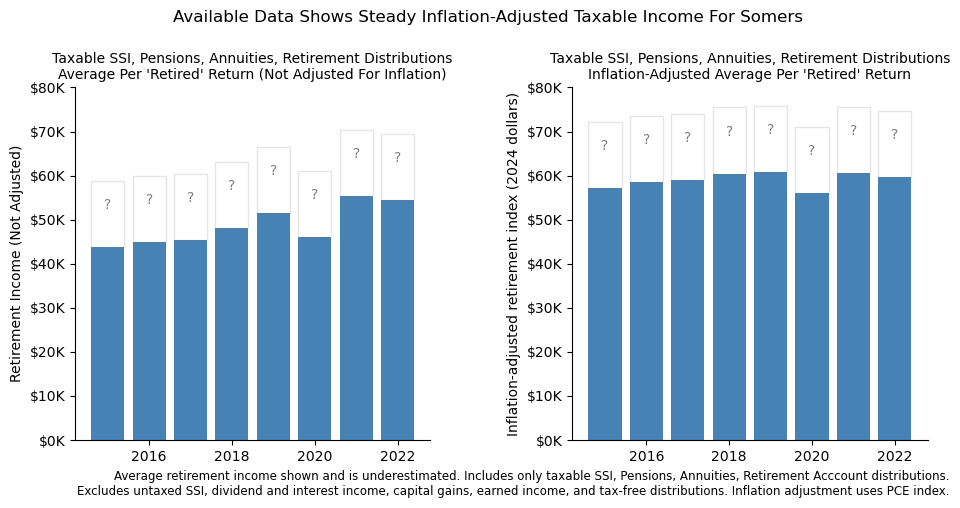

In [55]:

_df = town_total_income[town_total_income['Number of elderly returns'] > 0].query('Town == "Somers"')


fig, axs = plt.subplots(1, 2, figsize=(11,5), gridspec_kw={'wspace':.4})

fig.suptitle("Available Data Shows Steady Inflation-Adjusted Taxable Income For Somers")

# left side
ax = axs[0]

bars = ax.bar(_df['Year'],
       _df['Retirement Income Per Return'],
       facecolor='steelblue', )

for bar in bars:
    height = bar.get_height() + 7000
    ax.annotate("?",
                xy=(bar.get_x() + bar.get_width() / 2, height), #
                xytext=(0, 3), # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', color='gray')

ax.bar(_df['Year'],
       _df.shape[0]*[15000],
       bottom=_df['Retirement Income Per Return'],
       edgecolor='gray', facecolor='none', alpha=.2)
sns.despine()

ax.set_ylabel("Retirement Income (Not Adjusted)")
ax.yaxis.set_major_formatter(dollar_k_formatter)
ax.set_ylim(top=80000)

ax.set_title("Taxable SSI, Pensions, Annuities, Retirement Distributions\nAverage Per 'Retired' Return (Not Adjusted For Inflation)",
            fontsize=10)


# right side
ax = axs[1]

ax.set_title("Taxable SSI, Pensions, Annuities, Retirement Distributions\nInflation-Adjusted Average Per 'Retired' Return",
            fontsize=10)

_df = town_total_income[town_total_income['Number of elderly returns'] > 0].query('Town == "Granby"')

bars = ax.bar(_df['Year'],
       _df['Retirement Income Index (2024 dollars)'],
       facecolor='steelblue', )

for bar in bars:
    height = bar.get_height() + 7000
    ax.annotate("?",
                xy=(bar.get_x() + bar.get_width() / 2, height), #
                xytext=(0, 3), # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', color='gray')

ax.bar(_df['Year'],
       _df.shape[0]*[15000],
       bottom=_df['Retirement Income Index (2024 dollars)'],
       edgecolor='gray', facecolor='none', alpha=.2)
sns.despine()

ax.set_ylabel("Inflation-adjusted retirement index (2024 dollars)")
ax.yaxis.set_major_formatter(dollar_k_formatter)
ax.set_ylim(top=80000)

plt.subplots_adjust(top=.825, bottom=0.12)

line1 = "Average retirement income shown and is underestimated. Includes only taxable SSI, Pensions, Annuities, Retirement Acccount distributions."
line2 = "\nExcludes untaxed SSI, "
line3 = "dividend and interest income, capital gains, earned income, and tax-free distributions. Inflation adjustment uses PCE index."
fig.text(.92, .01, line1 + line2 + line3, ha='right', fontsize=8.5)

plt.savefig(f"./charts/social_security/real_retirement_index_somers.png", dpi=200, metadata=png_metadata)

plt.show()

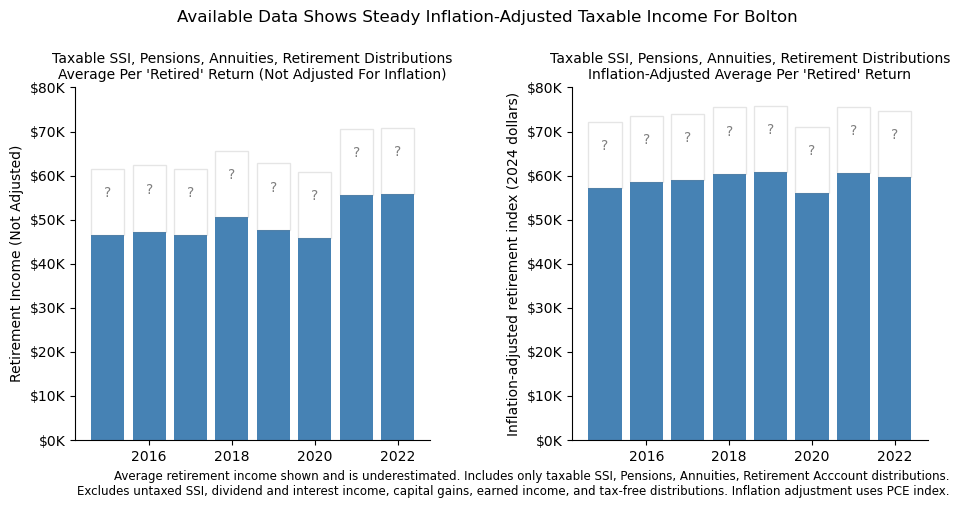

In [56]:

_df = town_total_income[town_total_income['Number of elderly returns'] > 0].query('Town == "Bolton"')


fig, axs = plt.subplots(1, 2, figsize=(11,5), gridspec_kw={'wspace':.4})

fig.suptitle("Available Data Shows Steady Inflation-Adjusted Taxable Income For Bolton")

# left side
ax = axs[0]

bars = ax.bar(_df['Year'],
       _df['Retirement Income Per Return'],
       facecolor='steelblue', )

for bar in bars:
    height = bar.get_height() + 7000
    ax.annotate("?",
                xy=(bar.get_x() + bar.get_width() / 2, height), #
                xytext=(0, 3), # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', color='gray')

ax.bar(_df['Year'],
       _df.shape[0]*[15000],
       bottom=_df['Retirement Income Per Return'],
       edgecolor='gray', facecolor='none', alpha=.2)
sns.despine()

ax.set_ylabel("Retirement Income (Not Adjusted)")
ax.yaxis.set_major_formatter(dollar_k_formatter)
ax.set_ylim(top=80000)

ax.set_title("Taxable SSI, Pensions, Annuities, Retirement Distributions\nAverage Per 'Retired' Return (Not Adjusted For Inflation)",
            fontsize=10)


# right side
ax = axs[1]

ax.set_title("Taxable SSI, Pensions, Annuities, Retirement Distributions\nInflation-Adjusted Average Per 'Retired' Return",
            fontsize=10)

_df = town_total_income[town_total_income['Number of elderly returns'] > 0].query('Town == "Granby"')

bars = ax.bar(_df['Year'],
       _df['Retirement Income Index (2024 dollars)'],
       facecolor='steelblue', )

for bar in bars:
    height = bar.get_height() + 7000
    ax.annotate("?",
                xy=(bar.get_x() + bar.get_width() / 2, height), #
                xytext=(0, 3), # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', color='gray')

ax.bar(_df['Year'],
       _df.shape[0]*[15000],
       bottom=_df['Retirement Income Index (2024 dollars)'],
       edgecolor='gray', facecolor='none', alpha=.2)
sns.despine()

ax.set_ylabel("Inflation-adjusted retirement index (2024 dollars)")
ax.yaxis.set_major_formatter(dollar_k_formatter)
ax.set_ylim(top=80000)

plt.subplots_adjust(top=.825, bottom=0.12)

line1 = "Average retirement income shown and is underestimated. Includes only taxable SSI, Pensions, Annuities, Retirement Acccount distributions."
line2 = "\nExcludes untaxed SSI, "
line3 = "dividend and interest income, capital gains, earned income, and tax-free distributions. Inflation adjustment uses PCE index."
fig.text(.92, .01, line1 + line2 + line3, ha='right', fontsize=8.5)

plt.savefig(f"./charts/social_security/real_retirement_index_bolton.png", dpi=200, metadata=png_metadata)

plt.show()

### Nominal income distributions

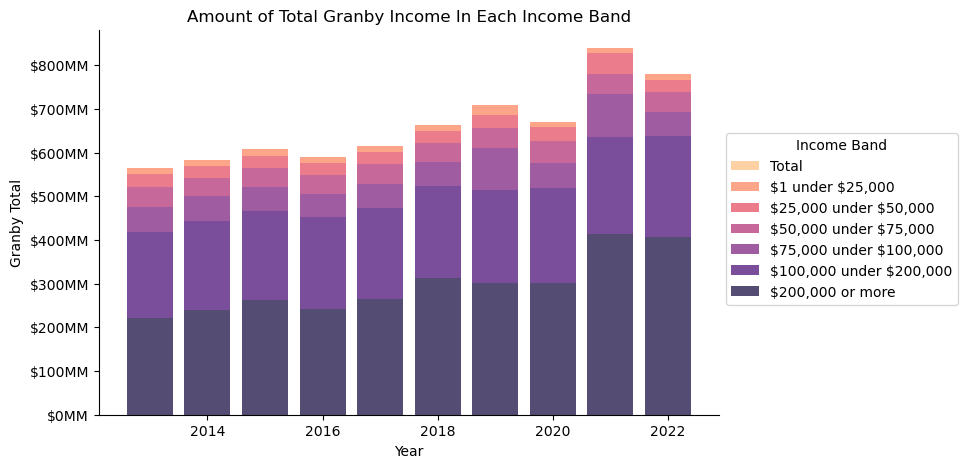

In [57]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(town_band_income[town_band_income.Town == 'Granby'],
             x="Year", weights='Total income Amount',
             palette="magma_r", discrete=True, edgecolor=None, shrink=.8,
            hue='Income Band', multiple='stack', ax=ax)

ax.yaxis.set_major_formatter(dollar_mm_formatter)

# Add labels and title
ax.set_ylabel("Granby Total")
ax.set_title("Amount of Total Granby Income In Each Income Band")

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, .75))
sns.despine()
plt.show()

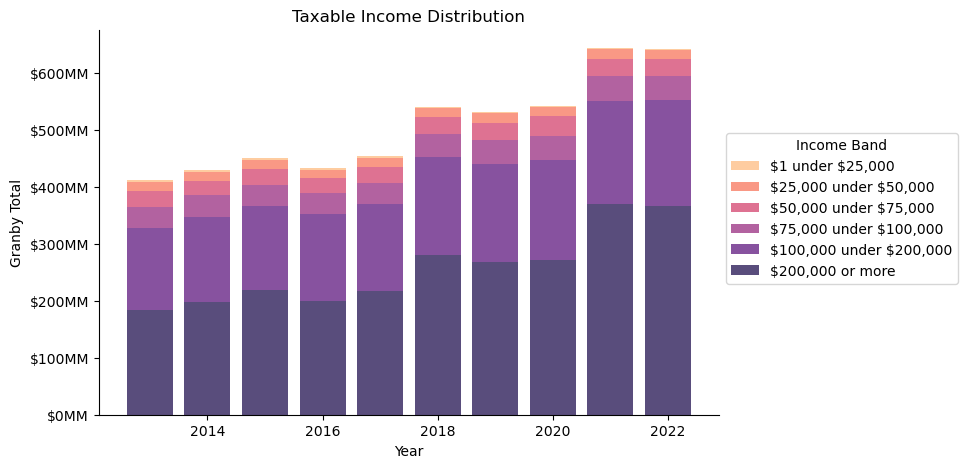

In [58]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(granby_incomes, x="Year", weights='Taxable income Amount',
             palette="magma_r", discrete=True, edgecolor=None, shrink=.8,
            hue='Income Band', multiple='stack', ax=ax)

ax.yaxis.set_major_formatter(dollar_mm_formatter)

# Add labels and title
ax.set_ylabel("Granby Total")
ax.set_title("Taxable Income Distribution")

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, .75))
sns.despine()
plt.show()

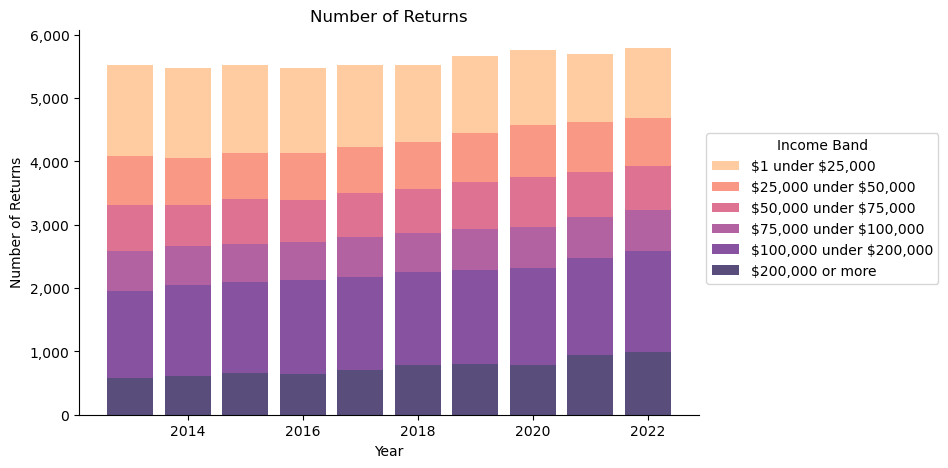

In [59]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(granby_incomes, x="Year", weights='Number of returns',
             palette="magma_r", discrete=True, edgecolor=None, shrink=.8,
            hue='Income Band', multiple='stack', ax=ax)

ax.yaxis.set_major_formatter(comma_formatter)

# Add labels and title
ax.set_ylabel("Number of Returns")
ax.set_title("Number of Returns")
sns.despine()
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, .75))
plt.show()